# Intérprete de Lengua de Señas Colombianas (LSC) con landmarks de mano — V3

**V3 — Añade vector normal de la palma y volúmenes con signo para detección de quiralidad**
(distingue palma de dorso de la mano). Features de nodo: 10-dim → 18-dim.
Features tabulares: 118-dim → 126-dim.

# Intérprete de Lengua de Señas Colombiana (LSC) con landmarks de mano

Este notebook organiza el experimento para comparar tres familias de modelos sobre la misma representación base obtenida con **MediaPipe Hands**:

1. **Modelos clásicos de ML** sobre un vector plano de 63 características.
2. **MLP** sobre el mismo vector plano.
3. **GCN** sobre un grafo anatómico de la mano, donde cada landmark es un nodo y las conexiones de MediaPipe forman las aristas.

El objetivo no es solo reportar la mejor precisión, sino explicar si la estructura de grafo ayuda a reconocer letras al incorporar la geometría natural de dedos, palma y muñeca.


## 1. Hipótesis y criterio de comparación

Cada imagen se transforma en 21 landmarks `(x, y, z)`. Primero se normalizan para reducir variaciones de posición y escala: se centra la mano en la muñeca y se divide por la máxima distancia desde la muñeca.

Después se comparan dos representaciones:

- **Vector plano `(63,)`**: concatena los 21 puntos. Es útil para SVM, Random Forest, KNN y MLP, pero el modelo debe aprender por sí solo qué coordenadas están conectadas anatómicamente.
- **Grafo `(21 nodos, 3 features)`**: conserva explícitamente la topología de la mano. Una GCN agrega información entre landmarks vecinos, por ejemplo falanges de un mismo dedo o conexiones de la palma.

Para demostrar mejor el punto, la exactitud (`accuracy`) no basta. También se reportan **macro-F1**, **weighted-F1**, matrices de confusión, curvas de entrenamiento y F1 por clase. Macro-F1 es clave si algunas letras tienen menos muestras.


## 2. Instalación e imports

Ejecuta esta celda en Colab o en un entorno limpio. Si ya tienes las dependencias instaladas, puedes omitir la instalación.


In [1]:
# En Colab puede tardar unos minutos. PyTorch Geometric se usa para la GCN.
!pip -q install mediapipe opencv-python scikit-learn seaborn joblib tensorflow torch torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.0 MB/s eta 0:00:00


In [2]:
import os
import json
import random
from pathlib import Path
from getpass import getpass

import cv2
import joblib
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Configuración del proyecto

Ajusta estas rutas según el entorno. En Colab, `DATASET_ROOT` suele apuntar a la carpeta descargada por Roboflow o Kaggle. En local, puedes usar la raíz del repositorio si allí están los CSV e imágenes.


In [ ]:
# Rutas principales
# DATASET_ROOT = Path('/content/LSC-1') if Path('/content/LSC-1').exists() else Path('.')
# MEDIAPIPE_MODEL_PATH = Path('/content/hand_landmarker.task') if Path('/content/hand_landmarker.task').exists() else Path('hand_landmarker.task')
# NORMALIZED_DATASET_PATH = DATASET_ROOT / 'dataset_senas_normalizado.csv'
# ARTIFACTS_DIR = Path('model_artifacts')

# # Conexiones anatómicas de MediaPipe Hands para los 21 landmarks.
# # Se usan tanto para dibujar como para construir el grafo de la GCN.
# HAND_CONNECTIONS = [
#     (0, 1), (1, 2), (2, 3), (3, 4),
#     (0, 5), (5, 6), (6, 7), (7, 8),
#     (5, 9), (9, 10), (10, 11), (11, 12),
#     (9, 13), (13, 14), (14, 15), (15, 16),
#     (13, 17), (17, 18), (18, 19), (19, 20),
#     (0, 17),
# ]

# print('DATASET_ROOT:', DATASET_ROOT.resolve())
# print('NORMALIZED_DATASET_PATH:', NORMALIZED_DATASET_PATH)
# print('MEDIAPIPE_MODEL_PATH:', MEDIAPIPE_MODEL_PATH)


In [3]:
# Rutas principales KAGGLE VERSION
DATASET_ROOT = Path('/content') if Path('/content').exists() else Path('.')
MEDIAPIPE_MODEL_PATH = Path('/content/hand_landmarker.task') if Path('/content/hand_landmarker.task').exists() else Path('hand_landmarker.task')
NORMALIZED_DATASET_PATH = DATASET_ROOT / 'dataset_kaggle_normalizado.csv'
ARTIFACTS_DIR = Path('model_artifacts_kaggle')

# Conexiones anatómicas de MediaPipe Hands para los 21 landmarks.
# Se usan tanto para dibujar como para construir el grafo de la GCN.
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17),
]

print('DATASET_ROOT:', DATASET_ROOT.resolve())
print('NORMALIZED_DATASET_PATH:', NORMALIZED_DATASET_PATH)
print('MEDIAPIPE_MODEL_PATH:', MEDIAPIPE_MODEL_PATH)


DATASET_ROOT: /content
NORMALIZED_DATASET_PATH: /content/dataset_kaggle_normalizado.csv
MEDIAPIPE_MODEL_PATH: hand_landmarker.task


## 4. Descarga opcional del detector y del dataset

Estas celdas son opcionales. Úsalas solo si todavía no tienes `hand_landmarker.task` o el dataset en el entorno. Para Roboflow se evita dejar la API key escrita dentro del notebook.


In [4]:
# Descargar el modelo de MediaPipe Hands si no existe.
if not MEDIAPIPE_MODEL_PATH.exists():
    !wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
    MEDIAPIPE_MODEL_PATH = Path('hand_landmarker.task')

print('Modelo MediaPipe disponible en:', MEDIAPIPE_MODEL_PATH)


Modelo MediaPipe disponible en: hand_landmarker.task


In [6]:
# Opción A: KaggleHub
# Descomenta si usarás el dataset de Kaggle.
!pip -q install kagglehub
import kagglehub
kagglehub.login()
DATASET_ROOT = Path(kagglehub.dataset_download('oscarstep/dataset-lsc-modelo'))
print('Dataset descargado en:', DATASET_ROOT)


Using Colab cache for faster access to the 'dataset-lsc-modelo' dataset.
Dataset descargado en: /kaggle/input/dataset-lsc-modelo


In [ ]:
!pip -q install roboflow
from roboflow import Roboflow
api_key = "mhGZso3MElKhU5ewcliD"
rf = Roboflow(api_key=api_key)
project = rf.workspace('yeison-adrian-caceres-torres').project('lsc-oowco-ytwc4')
dataset = project.version(1).download('multiclass')
DATASET_ROOT = Path(dataset.location)
print('Dataset descargado en:', DATASET_ROOT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LSC-1 in multiclass:: 100%|██████████| 2906/2906 [00:18<00:00, 158.80it/s]


Dataset descargado en: /content/LSC-1


## 5. Unificar imágenes y etiquetas

Roboflow suele entregar carpetas `train`, `valid` y `test`, cada una con `_classes.csv`. Esta celda mueve todas las imágenes a `all_images/` y construye un `merged_classes.csv` único. Si ya tienes esos archivos, puedes saltarla.


In [ ]:
# import csv
# import shutil

# IMAGE_EXTS = ('.jpg', '.jpeg', '.png')
# SUBFOLDERS = ['train', 'valid', 'test']


# def ensure_dir(path):
#     Path(path).mkdir(parents=True, exist_ok=True)


# def unique_name(dest_dir, filename):
#     base, ext = os.path.splitext(filename)
#     candidate = filename
#     i = 1
#     while (Path(dest_dir) / candidate).exists():
#         candidate = f'{base}_{i}{ext}'
#         i += 1
#     return candidate


# def move_images(root, dest_folder):
#     mapping = {}
#     ensure_dir(dest_folder)

#     for sub in SUBFOLDERS:
#         subdir = Path(root) / sub
#         if not subdir.is_dir():
#             continue

#         for src in subdir.iterdir():
#             if not src.is_file() or src.suffix.lower() not in IMAGE_EXTS:
#                 continue

#             new_name = src.name
#             dest_path = Path(dest_folder) / new_name
#             if dest_path.exists():
#                 new_name = unique_name(dest_folder, src.name)
#                 dest_path = Path(dest_folder) / new_name

#             shutil.move(str(src), str(dest_path))
#             mapping[src.name] = new_name

#     return mapping


# def merge_csvs(root, mapping, out_csv_name='merged_classes.csv'):
#     header = None
#     rows = []

#     for sub in SUBFOLDERS:
#         csv_path = Path(root) / sub / '_classes.csv'
#         if not csv_path.is_file():
#             continue

#         with csv_path.open(newline='', encoding='utf-8') as f:
#             reader = csv.reader(f)
#             try:
#                 current_header = next(reader)
#             except StopIteration:
#                 continue

#             if header is None:
#                 header = current_header

#             for row in reader:
#                 if not row:
#                     continue
#                 row[0] = mapping.get(row[0], row[0])
#                 rows.append(row)

#     if header is None:
#         return None

#     out_path = Path(root) / out_csv_name
#     with out_path.open('w', newline='', encoding='utf-8') as f:
#         writer = csv.writer(f)
#         writer.writerow(header)
#         writer.writerows(rows)

#     return out_path


# all_images_dir = DATASET_ROOT / 'all_images'
# merged_csv_path = DATASET_ROOT / 'merged_classes.csv'

# if merged_csv_path.exists() and all_images_dir.exists():
#     print('Ya existen merged_classes.csv y all_images/. No se modificó el dataset.')
# else:
#     print('Unificando imágenes en:', all_images_dir)
#     mapping = move_images(DATASET_ROOT, all_images_dir)
#     merged = merge_csvs(DATASET_ROOT, mapping)
#     print('Imágenes movidas:', len(mapping))
#     print('CSV unido:', merged)


Unificando imágenes en: /root/.cache/kagglehub/datasets/oscarstep/dataset-lsc-modelo/versions/1/all_images
Imágenes movidas: 0
CSV unido: None


## 6. Extracción de landmarks con MediaPipe y normalización

Esta etapa convierte cada imagen en un vector de 63 valores. La normalización aplicada es:

1. Convertir los 21 landmarks a una matriz `(21, 3)`.
2. Restar la muñeca, landmark `0`, a todos los puntos.
3. Dividir por la máxima distancia a la muñeca para reducir sensibilidad al tamaño de la mano.

El CSV resultante es la base común de todos los modelos.


In [7]:
#@title **Legacy del dataset descartado y declaracion de funciones**
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def _to_numpy_coords(landmarks):
    if isinstance(landmarks, np.ndarray):
        coords = landmarks.astype(np.float32)
    else:
        coords = np.array([[lm.x, lm.y, getattr(lm, 'z', 0.0)] for lm in landmarks], dtype=np.float32)
    if coords.ndim != 2 or coords.shape[0] == 0:
        raise ValueError('coords debe tener forma (N, 2) o (N, 3)')
    return coords

def normalize_landmarks(coords):
    coords = _to_numpy_coords(coords)
    is_2d = coords.shape[1] == 2
    if is_2d:
        coords = np.hstack([coords, np.zeros((coords.shape[0], 1), dtype=np.float32)])

    wrist = coords[0]
    centered = coords - wrist
    scale = np.linalg.norm(centered, axis=1).max()
    if scale > 0:
        centered = centered / scale

    ref = centered[9]
    angle = np.arctan2(ref[1], ref[0]) if np.linalg.norm(ref[:2]) > 0 else 0.0
    c, s = np.cos(-angle), np.sin(-angle)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    centered = (R @ centered.T).T

    return centered[:, :2] if is_2d else centered

def build_features(coords, edges, base_connections=None):
    coords_norm = normalize_landmarks(coords)
    is_2d = coords_norm.shape[1] == 2
    coords_feat = coords_norm
    if is_2d:
        coords_feat = np.hstack([coords_norm, np.zeros((coords_norm.shape[0], 1), dtype=np.float32)])

    parent_map = {}
    for parent, child in (base_connections or edges):
        if child not in parent_map:
            parent_map[child] = parent

    bone_vecs = np.zeros_like(coords_feat)
    for idx in range(coords_feat.shape[0]):
        parent = parent_map.get(idx)
        if parent is not None:
            bone_vecs[idx] = coords_feat[idx] - coords_feat[parent]

    dist_center = np.linalg.norm(coords_feat, axis=1, keepdims=True)
    x, y, z = coords_feat[:, 0], coords_feat[:, 1], coords_feat[:, 2]
    eps = np.finfo(np.float32).eps
    polar_r = np.sqrt(np.maximum(x**2 + y**2, eps)).reshape(-1, 1)
    azimuth = np.arctan2(y, x).reshape(-1, 1)
    elevation = np.arctan2(z, np.sqrt(np.maximum(x**2 + y**2, eps))).reshape(-1, 1)
    # ── V3: Compute palm normal and signed volumes ──
    palm_nx, palm_ny, palm_nz = compute_palm_normal(coords_feat)
    signed_vols = compute_signed_volumes(coords_feat)

    # Expand global features to per-node (same value for all 21 nodes)
    palm_normal_features = np.tile(np.array([[palm_nx, palm_ny, palm_nz]], dtype=np.float32), (coords_feat.shape[0], 1))
    signed_vol_features = np.tile(signed_vols.reshape(1, -1), (coords_feat.shape[0], 1))

    # V3: 10 original + 3 palm normal + 5 signed volumes = 18 features per node
    node_features = np.concatenate([coords_feat, bone_vecs, dist_center,
                                     polar_r, azimuth, elevation,
                                     palm_normal_features, signed_vol_features], axis=1).astype(np.float32)
    return coords_norm, node_features

def normalizar_landmarks(landmarks):
    coords = normalize_landmarks(landmarks)
    return coords.reshape(-1)

def create_detector(model_path):
    base_options = python.BaseOptions(model_asset_path=str(model_path))
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return vision.HandLandmarker.create_from_options(options)

def procesar_imagen_a_vector(detector, image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if not detection_result.hand_landmarks:
        return None

    return normalizar_landmarks(detection_result.hand_landmarks[0])

def extraer_dataset_normalizado(dataset_root, model_path, overwrite=False):
    dataset_root = Path(dataset_root)
    out_path = dataset_root / 'dataset_senas_normalizado.csv'

    if out_path.exists() and not overwrite:
        print('Dataset normalizado existente:', out_path)
        return out_path

    merged_csv = dataset_root / 'merged_classes.csv'
    images_dir = dataset_root / 'all_images'

    if not merged_csv.is_file():
        raise FileNotFoundError(f'No se encontró {merged_csv}')
    if not images_dir.is_dir():
        raise FileNotFoundError(f'No se encontró {images_dir}')
    if not Path(model_path).is_file():
        raise FileNotFoundError(f'No se encontró el modelo MediaPipe: {model_path}')

    df_classes = pd.read_csv(merged_csv)
    filename_col = df_classes.columns[0]
    label_cols = list(df_classes.columns[1:])
    detector = create_detector(model_path)

    data = []
    labels = []
    skipped = 0

    for i, row in df_classes.iterrows():
        label_values = row[label_cols].astype(float)
        if label_values.sum() == 0:
            skipped += 1
            continue

        label = label_cols[int(label_values.values.argmax())]
        image_path = images_dir / str(row[filename_col])
        if not image_path.is_file():
            skipped += 1
            continue

        vector = procesar_imagen_a_vector(detector, image_path)
        if vector is None:
            skipped += 1
            continue

        data.append(vector)
        labels.append(label)

        if len(data) % 100 == 0:
            print(f'Procesadas: {len(data)} | Saltadas: {skipped}')

    if not data:
        raise RuntimeError('No se extrajeron landmarks válidos.')

    columns = [f'punto_{i}_{axis}' for i in range(21) for axis in ['x', 'y', 'z']]
    df_out = pd.DataFrame(data, columns=columns)
    df_out['etiqueta'] = labels
    df_out.to_csv(out_path, index=False)

    print('CSV normalizado guardado en:', out_path)
    print('Muestras válidas:', len(df_out), '| Saltadas:', skipped)
    return out_path

# NORMALIZED_DATASET_PATH = extraer_dataset_normalizado(DATASET_ROOT, MEDIAPIPE_MODEL_PATH, overwrite=False)
# ─────────────────────────────────────────────────────────────────
# V3 ADDITION: Palm normal vector and signed volume (chirality)
# These features help distinguish front-of-hand from back-of-hand.
# A flipped hand will produce inverted signs, giving models
# a mathematical basis for chirality detection.
# ─────────────────────────────────────────────────────────────────

def compute_palm_normal(coords_feat):
    """
    Compute the palm normal vector using wrist (0), index MCP (5),
    and pinky MCP (17). Uses the normalized coordinates.

    Returns (norm_x, norm_y, norm_z).
    For right-hand coordinate system with palm facing camera:
      norm_z is typically positive.
    When back of hand faces camera: norm_z is typically negative.
    """
    c = coords_feat.astype(np.float32)
    v1 = c[5] - c[0]   # wrist -> index MCP
    v2 = c[17] - c[0]  # wrist -> pinky MCP
    normal = np.cross(v1, v2)
    norm_len = np.linalg.norm(normal)
    if norm_len > 1e-9:
        normal = normal / norm_len
    return float(normal[0]), float(normal[1]), float(normal[2])


def compute_signed_volumes(coords_feat):
    """
    Compute signed tetrahedron volumes using scalar triple product.
    Base: wrist(0), index_MCP(5), pinky_MCP(17)
    Apexes: each fingertip (4, 8, 12, 16, 20)

    Volume = (1/6) * w . (u x v)  where:
      u = index_MCP - wrist
      v = pinky_MCP - wrist
      w = fingertip - wrist

    Sign changes when hand is flipped -> chirality feature.
    Returns array of 5 signed volumes (one per fingertip).
    """
    c = coords_feat.astype(np.float32)
    O = c[0]   # wrist
    A = c[5]   # index MCP
    B = c[17]  # pinky MCP

    u = A - O
    v = B - O
    cross_uv = np.cross(u, v)

    volumes = []
    for tip_idx in [4, 8, 12, 16, 20]:
        w = c[tip_idx] - O
        vol = np.dot(w, cross_uv) / 6.0  # scalar triple product / 6
        volumes.append(float(vol))
    return np.array(volumes, dtype=np.float32)



In [8]:
#@title **Extracción del dataset de Kaggle**
def extraer_dataset_desde_carpetas(root_dir, detector_modelo, out_csv_name='dataset_kaggle_normalizado.csv'):
    root_path = Path(root_dir)
    detector = create_detector(detector_modelo)

    data = []
    labels = []
    skipped = 0

    # Listar carpetas (cada una representa una clase/letra)
    carpetas_clases = [d for d in root_path.iterdir() if d.is_dir() and d.name != 'all_images']

    print(f'Procesando carpetas en: {root_path}')

    for carpeta in carpetas_clases:
        label = carpeta.name.upper() # Convertir nombre de carpeta a etiqueta (A, B, C...)
        imagenes = list(carpeta.glob('*.jpg')) + list(carpeta.glob('*.png')) + list(carpeta.glob('*.jpeg'))

        print(f'Procesando clase {label}: {len(imagenes)} imágenes encontradas.')

        for img_path in imagenes:
            vector = procesar_imagen_a_vector(detector, img_path)
            if vector is not None:
                data.append(vector)
                labels.append(label)
            else:
                skipped += 1

    if not data:
        print('No se pudieron extraer landmarks del dataset de carpetas.')
        return None

    columns = [f'punto_{i}_{axis}' for i in range(21) for axis in ['x', 'y', 'z']]
    df_out = pd.DataFrame(data, columns=columns)
    df_out['etiqueta'] = labels

    # Cambio: Guardar en /content/ en lugar de la raíz del dataset
    out_path = Path('/content') / out_csv_name
    df_out.to_csv(out_path, index=False)
    print(f'Dataset de Kaggle guardado en: {out_path}')
    print(f'Total muestras extraídas: {len(df_out)}')
    print(f'Total muestras descartadas (no se detectó mano): {skipped}')
    return out_path

# Ejecutar extracción para el dataset de Kaggle
KAGGLE_NORMALIZED_PATH = extraer_dataset_desde_carpetas(
    root_dir='/kaggle/input/dataset-lsc-modelo',
    detector_modelo=MEDIAPIPE_MODEL_PATH
)

Procesando carpetas en: /kaggle/input/dataset-lsc-modelo
Procesando clase N: 200 imágenes encontradas.
Procesando clase R: 200 imágenes encontradas.
Procesando clase B: 200 imágenes encontradas.
Procesando clase I: 200 imágenes encontradas.
Procesando clase F: 200 imágenes encontradas.
Procesando clase E: 200 imágenes encontradas.
Procesando clase U: 200 imágenes encontradas.
Procesando clase M: 200 imágenes encontradas.
Procesando clase X: 200 imágenes encontradas.
Procesando clase K: 200 imágenes encontradas.
Procesando clase Q: 200 imágenes encontradas.
Procesando clase Y: 200 imágenes encontradas.
Procesando clase A: 200 imágenes encontradas.
Procesando clase O: 200 imágenes encontradas.
Procesando clase T: 200 imágenes encontradas.
Procesando clase V: 200 imágenes encontradas.
Procesando clase C: 200 imágenes encontradas.
Procesando clase P: 200 imágenes encontradas.
Procesando clase L: 200 imágenes encontradas.
Procesando clase W: 200 imágenes encontradas.
Procesando clase D: 200

## 6.1. Verificación visual de MediaPipe sobre una imagen aleatoria

Esta celda toma una imagen aleatoria del dataset, vuelve a extraer los landmarks con MediaPipe y dibuja los 21 puntos y sus conexiones sobre la imagen original. Sirve para comprobar visualmente que la detección está funcionando antes de confiar en los modelos.

Nota: el CSV normalizado guarda las coordenadas centradas y escaladas, no las coordenadas absolutas en píxeles. Por eso, para superponer puntos sobre la imagen se vuelve a ejecutar MediaPipe sobre la imagen seleccionada y se muestra al lado su grafo normalizado.


In [ ]:
#@title **Legacy**
def detectar_landmarks_en_imagen(detector, image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'No se pudo leer la imagen: {image_path}')

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)
    return image_rgb, detection_result


def dibujar_landmarks_sobre_imagen(image_rgb, detection_result, connections=HAND_CONNECTIONS):
    annotated = image_rgb.copy()
    h, w, _ = annotated.shape

    if not detection_result.hand_landmarks:
        return annotated

    landmarks = detection_result.hand_landmarks[0]

    for start_idx, end_idx in connections:
        p1 = landmarks[start_idx]
        p2 = landmarks[end_idx]
        start = (int(p1.x * w), int(p1.y * h))
        end = (int(p2.x * w), int(p2.y * h))
        cv2.line(annotated, start, end, (76, 120, 168), 3)

    for idx, landmark in enumerate(landmarks):
        center = (int(landmark.x * w), int(landmark.y * h))
        cv2.circle(annotated, center, 6, (245, 133, 24), -1)
        cv2.putText(
            annotated,
            str(idx),
            (center[0] + 6, center[1] - 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.38,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return annotated


def seleccionar_imagen_aleatoria_con_mano(dataset_root, detector, max_intentos=100):
    dataset_root = Path(dataset_root)
    merged_csv = dataset_root / 'merged_classes.csv'
    images_dir = dataset_root / 'all_images'

    if not merged_csv.exists():
        raise FileNotFoundError(f'No se encontró {merged_csv}')
    if not images_dir.exists():
        raise FileNotFoundError(f'No se encontró {images_dir}')

    df_classes = pd.read_csv(merged_csv)
    filename_col = df_classes.columns[0]
    label_cols = list(df_classes.columns[1:])
    sampled_rows = df_classes.sample(frac=1, random_state=np.random.randint(0, 1_000_000)).head(max_intentos)

    for _, row in sampled_rows.iterrows():
        image_path = images_dir / str(row[filename_col])
        if not image_path.exists():
            continue

        image_rgb, detection_result = detectar_landmarks_en_imagen(detector, image_path)
        if detection_result.hand_landmarks:
            label_values = row[label_cols].astype(float)
            label = label_cols[int(label_values.values.argmax())] if label_values.sum() > 0 else 'sin etiqueta'
            return image_path, label, image_rgb, detection_result

    raise RuntimeError(f'No se detectó ninguna mano en {max_intentos} imágenes aleatorias.')


visual_detector = create_detector(MEDIAPIPE_MODEL_PATH)
image_path, label, image_rgb, detection_result = seleccionar_imagen_aleatoria_con_mano(DATASET_ROOT, visual_detector)
annotated_image = dibujar_landmarks_sobre_imagen(image_rgb, detection_result)
normalized_points = normalizar_landmarks(detection_result.hand_landmarks[0]).reshape(21, 3)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(annotated_image)
axes[0].set_title(f'Landmarks sobre imagen original | clase: {label}')
axes[0].axis('off')

points = normalized_points[:, :2]
for i, j in HAND_CONNECTIONS:
    axes[1].plot([points[i, 0], points[j, 0]], [-points[i, 1], -points[j, 1]], color='#4C78A8', linewidth=2)
axes[1].scatter(points[:, 0], -points[:, 1], s=70, color='#F58518', zorder=3)
for idx, (x, y) in enumerate(points):
    axes[1].text(x, -y, str(idx), fontsize=8, ha='center', va='center', color='white')
axes[1].set_title('Mismos landmarks después de normalizar')
axes[1].axis('equal')
axes[1].axis('off')

plt.suptitle(f'Imagen aleatoria: {image_path.name}', y=1.02)
plt.tight_layout()
plt.show()


FileNotFoundError: No se encontró /kaggle/input/dataset-lsc-modelo/merged_classes.csv

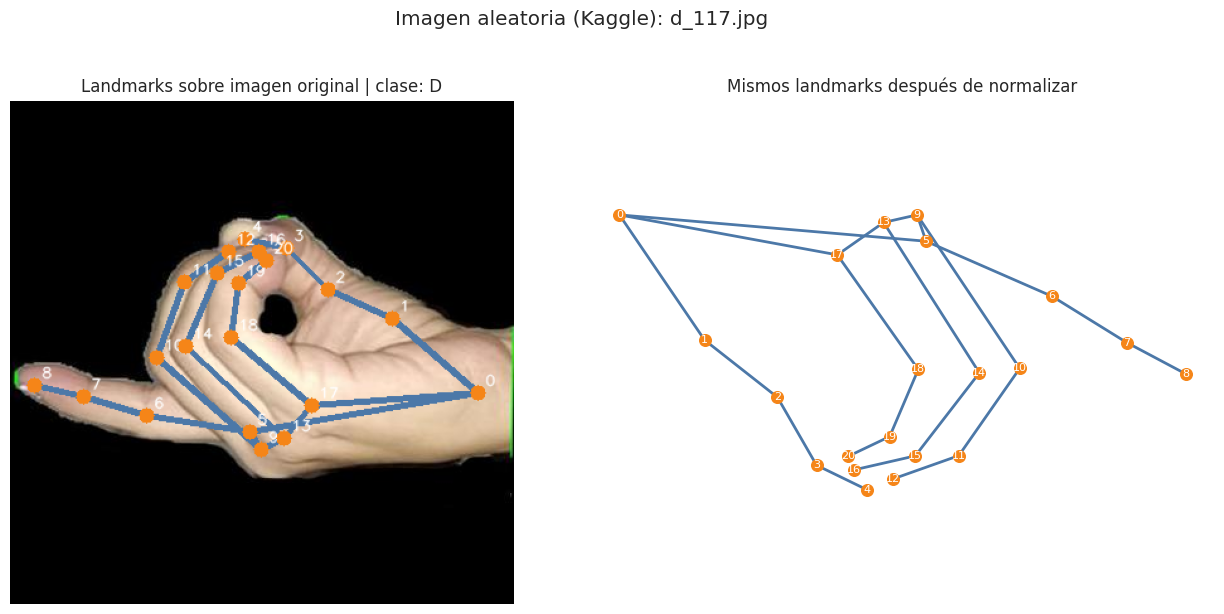

In [9]:
#@title **Seleccionar imagen aleatoria de kaggle**
def detectar_landmarks_en_imagen(detector, image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'No se pudo leer la imagen: {image_path}')

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)
    return image_rgb, detection_result


def dibujar_landmarks_sobre_imagen(image_rgb, detection_result, connections=HAND_CONNECTIONS):
    annotated = image_rgb.copy()
    h, w, _ = annotated.shape

    if not detection_result.hand_landmarks:
        return annotated

    landmarks = detection_result.hand_landmarks[0]

    for start_idx, end_idx in connections:
        p1 = landmarks[start_idx]
        p2 = landmarks[end_idx]
        start = (int(p1.x * w), int(p1.y * h))
        end = (int(p2.x * w), int(p2.y * h))
        cv2.line(annotated, start, end, (76, 120, 168), 3)

    for idx, landmark in enumerate(landmarks):
        center = (int(landmark.x * w), int(landmark.y * h))
        cv2.circle(annotated, center, 6, (245, 133, 24), -1)
        cv2.putText(
            annotated,
            str(idx),
            (center[0] + 6, center[1] - 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.38,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return annotated


def seleccionar_imagen_aleatoria_kaggle(dataset_root, detector, max_intentos=50):
    root_path = Path(dataset_root)
    # Listar carpetas de clases (A, B, C...)
    carpetas_clases = [d for d in root_path.iterdir() if d.is_dir() and d.name != 'all_images']

    if not carpetas_clases:
        raise FileNotFoundError(f'No se encontraron carpetas de clases en {dataset_root}')

    for _ in range(max_intentos):
        # Elegir una clase al azar
        carpeta_random = random.choice(carpetas_clases)
        label = carpeta_random.name.upper()

        # Elegir una imagen al azar de esa clase
        imagenes = list(carpeta_random.glob('*.jpg')) + list(carpeta_random.glob('*.png')) + list(carpeta_random.glob('*.jpeg'))
        if not imagenes:
            continue

        image_path = random.choice(imagenes)
        image_rgb, detection_result = detectar_landmarks_en_imagen(detector, image_path)

        if detection_result.hand_landmarks:
            return image_path, label, image_rgb, detection_result

    raise RuntimeError(f'No se detectó ninguna mano tras {max_intentos} intentos en el dataset de Kaggle.')


visual_detector = create_detector(MEDIAPIPE_MODEL_PATH)
kaggle_path = "/kaggle/input/dataset-lsc-modelo"

try:
    image_path, label, image_rgb, detection_result = seleccionar_imagen_aleatoria_kaggle(kaggle_path, visual_detector)
    annotated_image = dibujar_landmarks_sobre_imagen(image_rgb, detection_result)
    normalized_points = normalizar_landmarks(detection_result.hand_landmarks[0]).reshape(21, 3)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    axes[0].imshow(annotated_image)
    axes[0].set_title(f'Landmarks sobre imagen original | clase: {label}')
    axes[0].axis('off')

    points = normalized_points[:, :2]
    for i, j in HAND_CONNECTIONS:
        axes[1].plot([points[i, 0], points[j, 0]], [-points[i, 1], -points[j, 1]], color='#4C78A8', linewidth=2)
    axes[1].scatter(points[:, 0], -points[:, 1], s=70, color='#F58518', zorder=3)
    for idx, (x, y) in enumerate(points):
        axes[1].text(x, -y, str(idx), fontsize=8, ha='center', va='center', color='white')
    axes[1].set_title('Mismos landmarks después de normalizar')
    axes[1].axis('equal')
    axes[1].axis('off')

    plt.suptitle(f'Imagen aleatoria (Kaggle): {image_path.name}', y=1.02)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error al procesar el dataset de Kaggle: {e}")

## 7. Exploración rápida del dataset normalizado

Antes de entrenar conviene revisar el número de muestras, el balance de clases y la forma de las características. Si el dataset está desbalanceado, la macro-F1 y el F1 por clase serán más informativos que la exactitud global.


Forma del dataset: (2548, 64)
Número de características: 63
Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'T', 'U', 'V', 'W', 'X', 'Y']


,punto_0_x,punto_0_y,punto_0_z,punto_1_x,punto_1_y,punto_1_z,punto_2_x,punto_2_y,punto_2_z,punto_3_x,...,punto_18_x,punto_18_y,punto_18_z,punto_19_x,punto_19_y,punto_19_z,punto_20_x,punto_20_y,punto_20_z,etiqueta
0,0.0,0.0,0.0,0.210117,0.111684,-0.006650,0.450477,0.043221,-0.061046,0.603749,...,0.311870,-0.381223,-0.289978,0.268518,-0.345448,-0.252851,0.204996,-0.281110,-0.231075,N
1,0.0,0.0,0.0,-0.110994,-0.192428,-0.121433,-0.249428,-0.231394,-0.264093,-0.388875,...,-0.191242,0.317974,-0.487433,-0.276992,0.252753,-0.439851,-0.288237,0.195097,-0.408781,N
2,0.0,0.0,0.0,-0.121370,-0.112130,-0.234429,-0.146868,-0.245601,-0.405748,-0.082883,...,0.370478,-0.286239,-0.434595,0.316537,-0.399395,-0.448647,0.262970,-0.453850,-0.451844,N
3,0.0,0.0,0.0,0.086861,0.235076,-0.200580,0.171926,0.406667,-0.352695,0.171061,...,-0.255122,-0.177986,-0.440980,-0.322520,-0.114506,-0.420437,-0.277435,-0.133827,-0.392313,N
4,0.0,0.0,0.0,0.209022,-0.019500,-0.031948,0.385013,-0.165727,-0.072736,0.422661,...,-0.007693,-0.317071,-0.196661,-0.036470,-0.329134,-0.148700,-0.054967,-0.296212,-0.108175,N


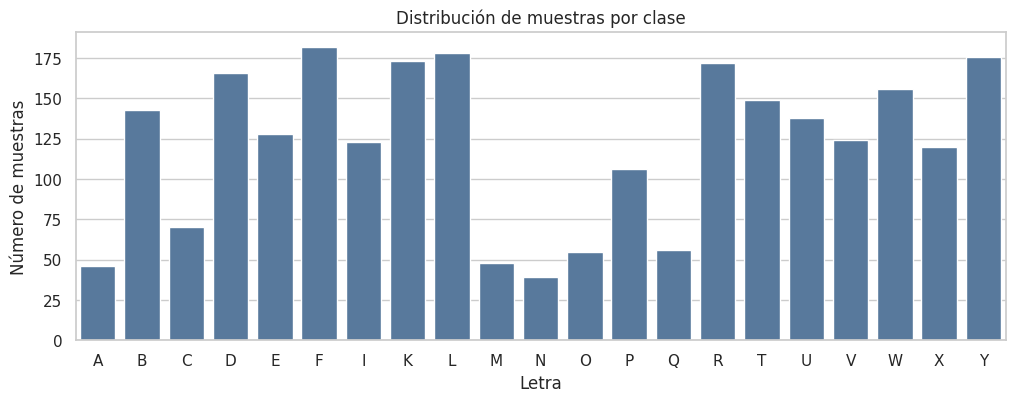

In [10]:
df = pd.read_csv(NORMALIZED_DATASET_PATH)
feature_columns = [c for c in df.columns if c != 'etiqueta']

print('Forma del dataset:', df.shape)
print('Número de características:', len(feature_columns))
print('Clases:', sorted(df['etiqueta'].unique()))
display(df.head())

class_counts = df['etiqueta'].value_counts().sort_index()
plt.figure(figsize=(12, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color='#4C78A8')
plt.title('Distribución de muestras por clase')
plt.xlabel('Letra')
plt.ylabel('Número de muestras')
plt.xticks(rotation=0)
plt.show()


### 7.1. Balanceo del dataset (Undersampling)

Dado que algunas letras tienen ~180 muestras y otras ~40, aplicamos un submuestreo para igualar las clases a un número base de muestras o al menos reducir la brecha, mejorando la robustez de la macro-F1.

Objetivo de muestras por clase (Balanceo Total): 182


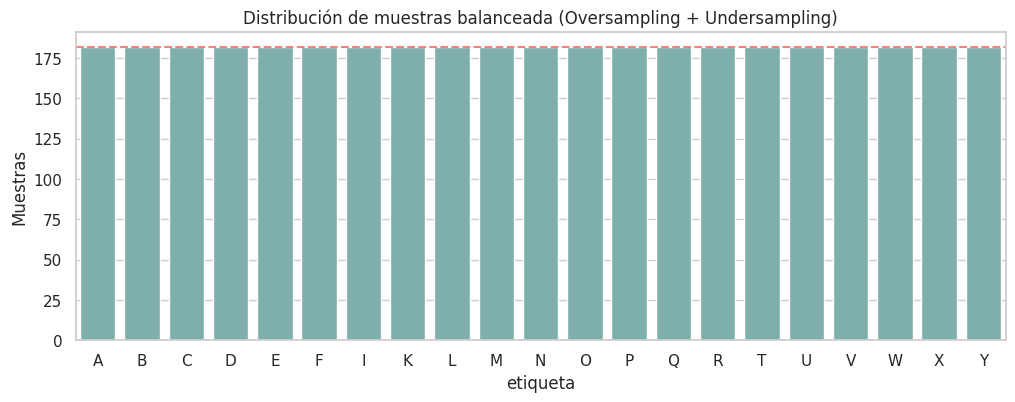

Nueva forma del dataset: (3822, 64)
Conteo por clase:
 etiqueta
A    182
B    182
C    182
D    182
E    182
F    182
I    182
K    182
L    182
M    182
N    182
O    182
P    182
Q    182
R    182
T    182
U    182
V    182
W    182
X    182
Y    182
Name: count, dtype: int64


In [11]:
from sklearn.utils import resample

# Definimos el número objetivo de muestras por clase.
# Para no perder demasiada información pero asegurar que las minoritarias suban,
# usaremos el máximo o un valor alto como 180.
target_samples = int(df['etiqueta'].value_counts().max())
print(f'Objetivo de muestras por clase (Balanceo Total): {target_samples}')

df_balanced_list = []
for label in df['etiqueta'].unique():
    df_class = df[df['etiqueta'] == label]

    if len(df_class) > target_samples:
        # Submuestreo para clases mayoritarias
        df_class_resampled = resample(df_class, replace=False, n_samples=target_samples, random_state=RANDOM_STATE)
    elif len(df_class) < target_samples:
        # Sobremuestreo para clases minoritarias (M, N, O, P, Q, A, C, etc.)
        df_class_resampled = resample(df_class, replace=True, n_samples=target_samples, random_state=RANDOM_STATE)
    else:
        df_class_resampled = df_class

    df_balanced_list.append(df_class_resampled)

df_balanced = pd.concat(df_balanced_list).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Actualizamos la variable global df y graficamos de nuevo
df = df_balanced
class_counts_new = df['etiqueta'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.barplot(x=class_counts_new.index, y=class_counts_new.values, color='#76b7b2')
plt.title('Distribución de muestras balanceada (Oversampling + Undersampling)')
plt.ylabel('Muestras')
plt.axhline(y=target_samples, color='red', linestyle='--', alpha=0.5)
plt.show()

print('Nueva forma del dataset:', df.shape)
print('Conteo por clase:\n', class_counts_new)

## 8. Split único para una comparación justa

Todos los modelos usarán los mismos índices de entrenamiento y prueba. Esto evita comparar modelos entrenados o evaluados con particiones distintas.


In [12]:
X_flat = df[feature_columns].values.astype(np.float32)
y_labels = df['etiqueta'].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
class_names = encoder.classes_
num_classes = len(class_names)

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

X_train_flat = X_flat[train_idx]
X_test_flat = X_flat[test_idx]
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

X_graph = X_flat.reshape(-1, 21, 3)
X_train_graph = X_graph[train_idx]
X_test_graph = X_graph[test_idx]
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

resultados_modelos = []
predicciones_test = {}
reportes_test = {}
historias_entrenamiento = {}

print('X_train_flat:', X_train_flat.shape)
print('X_test_flat:', X_test_flat.shape)
print('X_train_graph:', X_train_graph.shape)
print('Clases:', class_names)


X_train_flat: (3057, 63)
X_test_flat: (765, 63)
X_train_graph: (3057, 21, 3)
Clases: ['A' 'B' 'C' 'D' 'E' 'F' 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'T' 'U' 'V'
 'W' 'X' 'Y']


## 9. Features geométricas derivadas: distancias y ángulos

Esta sección se ubica **después del split único** porque usa las mismas muestras ya divididas para todos los modelos. A partir de los 21 landmarks normalizados se agregan descriptores geométricos que no requieren volver a procesar imágenes con MediaPipe:

- **Distancias anatómicas** entre landmarks conectados por la mano.
- **Distancias entre puntas de dedos** para capturar apertura/separación.
- **Distancias muñeca-puntas** para medir extensión relativa de cada dedo.
- **Ángulos articulares** para representar flexión de dedos.

Los modelos clásicos y la MLP usarán esta representación enriquecida. La GCN se mantiene con la representación de grafo `(21, 3)`, porque su ventaja buscada es aprender relaciones desde la topología anatómica.


### 9.0 V3 — Vector Normal de la Palma y Volúmenes con Signo (Quiralidad)

**Problema**: Las features anteriores (distancias, ángulos) son invariantes respecto a
si la mano se ve de frente (palma hacia la cámara) o de dorso. Una mano rotada 180°
produce features casi idénticas, y el modelo no puede distinguir frente de revés.

**Solución V3**:

1. **Vector normal de la palma** (3 valores): Producto cruz entre muñeca→MCP índice
   (landmark 5) y muñeca→MCP meñique (landmark 17). El componente Z indica hacia
   dónde mira la palma: Z positivo = palma hacia cámara, Z negativo = dorso.

2. **Volúmenes con signo — quiralidad** (5 valores): Volumen de tetraedros formados
   por la base palmar (muñeca + MCPs índice/meñique) y cada punta de dedo como ápice.
   Calculados con producto mixto: $V = \frac{1}{6} \vec{w} \cdot (\vec{u} \times \vec{v})$.
   Al voltear la mano, todos los volúmenes cambian de signo → feature nativa de quiralidad.

**Impacto en dimensionalidad**:
- Features tabulares: 118 + 8 = **126**
- Features de nodo (grafo): 10 + 8 = **18 por nodo**


In [16]:
from itertools import combinations

TIP_INDICES = [4, 8, 12, 16, 20]
FINGER_CHAINS = {
    'pulgar': [0, 1, 2, 3, 4],
    'indice': [0, 5, 6, 7, 8],
    'medio': [0, 9, 10, 11, 12],
    'anular': [0, 13, 14, 15, 16],
    'menique': [0, 17, 18, 19, 20],
}
PALM_ANGLE_TRIPLES = [
    ('palma_indice_medio', 5, 0, 9),
    ('palma_medio_anular', 9, 0, 13),
    ('palma_anular_menique', 13, 0, 17),
    ('palma_indice_menique', 5, 0, 17),
]


def distancia_landmarks(points, i, j):
    return float(np.linalg.norm(points[i] - points[j]))


def angulo_landmarks(points, a, b, c):
    v1 = points[a] - points[b]
    v2 = points[c] - points[b]
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    cos_angle = np.clip(np.dot(v1, v2) / denom, -1.0, 1.0)
    return float(np.arccos(cos_angle) / np.pi)  # 0..1 para facilitar entrenamiento


def construir_features_geometricas(X_graph_values, flat_feature_names=None):
    flat_feature_names = list(flat_feature_names or [f'punto_{i}_{axis}' for i in range(21) for axis in ['x', 'y', 'z']])

    bone_pairs = list(HAND_CONNECTIONS)
    tip_pairs = list(combinations(TIP_INDICES, 2))
    wrist_tip_pairs = [(0, tip) for tip in TIP_INDICES]

    finger_angle_triples = []
    for finger_name, chain in FINGER_CHAINS.items():
        for a, b, c in zip(chain[:-2], chain[1:-1], chain[2:]):
            finger_angle_triples.append((finger_name, a, b, c))

    feature_names = []
    feature_names.extend(flat_feature_names)
    feature_names.extend([f'dist_bone_{i}_{j}' for i, j in bone_pairs])
    feature_names.extend([f'dist_tip_{i}_{j}' for i, j in tip_pairs])
    feature_names.extend([f'dist_wrist_tip_{i}_{j}' for i, j in wrist_tip_pairs])
    feature_names.extend([f'ang_{name}_{a}_{b}_{c}' for name, a, b, c in finger_angle_triples])
    feature_names.extend([f'ang_{name}_{a}_{b}_{c}' for name, a, b, c in PALM_ANGLE_TRIPLES])

    # ═══ V3: Nombres de features de palma y quiralidad ═══
    feature_names.extend([
        'palm_normal_x', 'palm_normal_y', 'palm_normal_z',
        'vol_tetra_thumb', 'vol_tetra_index', 'vol_tetra_middle',
        'vol_tetra_ring', 'vol_tetra_pinky'
    ])

    rows = []
    for points in X_graph_values:
        features = []
        features.extend(points.reshape(-1).tolist())
        features.extend(distancia_landmarks(points, i, j) for i, j in bone_pairs)
        features.extend(distancia_landmarks(points, i, j) for i, j in tip_pairs)
        features.extend(distancia_landmarks(points, i, j) for i, j in wrist_tip_pairs)
        features.extend(angulo_landmarks(points, a, b, c) for _, a, b, c in finger_angle_triples)
        features.extend(angulo_landmarks(points, a, b, c) for _, a, b, c in PALM_ANGLE_TRIPLES)

        # ── V3: Palm normal and chirality (8 new features) ──
        palm_nx, palm_ny, palm_nz = compute_palm_normal(points)
        vol_features = compute_signed_volumes(points)
        features.extend([palm_nx, palm_ny, palm_nz])
        for v in vol_features:
            features.append(float(v))
        rows.append(features)


    return np.array(rows, dtype=np.float32), feature_names


X_tabular, tabular_feature_names = construir_features_geometricas(X_graph, feature_columns)
X_train_tabular = X_tabular[train_idx]
X_test_tabular = X_tabular[test_idx]
TABULAR_FEATURE_STRATEGY = 'landmarks_63_plus_distances_angles_plus_palm_normal_plus_signed_volumes'

print('Features originales:', X_flat.shape[1])
print('Features tabulares enriquecidas:', X_tabular.shape[1])
print('Features agregadas:', X_tabular.shape[1] - X_flat.shape[1])
print('X_train_tabular:', X_train_tabular.shape)
print('X_test_tabular:', X_test_tabular.shape)


Features originales: 63
Features tabulares enriquecidas: 118
Features agregadas: 55
X_train_tabular: (3057, 118)
X_test_tabular: (765, 118)


## 10. Visualizar vector plano vs. grafo anatómico

La GCN recibe los mismos datos que el vector plano, pero con una estructura adicional: qué landmarks son vecinos en la mano. Esa estructura puede ayudar porque una letra no depende solo de puntos aislados, sino de relaciones locales entre falanges, nudillos y palma.


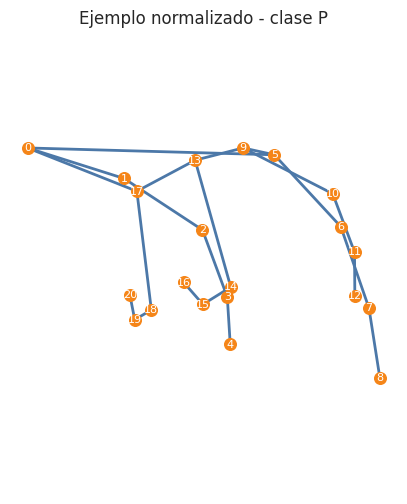

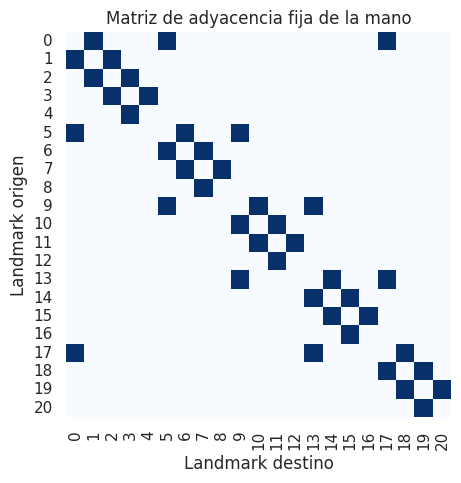

In [15]:
def plot_hand_graph(sample_graph, connections=HAND_CONNECTIONS, title='Grafo anatómico de una mano'):
    points = sample_graph[:, :2]
    plt.figure(figsize=(5, 6))
    for i, j in connections:
        plt.plot([points[i, 0], points[j, 0]], [-points[i, 1], -points[j, 1]], color='#4C78A8', linewidth=2)
    plt.scatter(points[:, 0], -points[:, 1], s=70, color='#F58518', zorder=3)
    for idx, (x, y) in enumerate(points):
        plt.text(x, -y, str(idx), fontsize=8, ha='center', va='center', color='white')
    plt.title(title)
    plt.axis('equal')
    plt.axis('off')
    plt.show()


A = np.zeros((21, 21), dtype=np.float32)
for i, j in HAND_CONNECTIONS:
    A[i, j] = 1.0
    A[j, i] = 1.0

plot_hand_graph(X_graph[0], title=f'Ejemplo normalizado - clase {y_labels[0]}')

plt.figure(figsize=(6, 5))
sns.heatmap(A, cmap='Blues', square=True, cbar=False)
plt.title('Matriz de adyacencia fija de la mano')
plt.xlabel('Landmark destino')
plt.ylabel('Landmark origen')
plt.show()


## 11. Funciones comunes de evaluación

Se usan las mismas métricas para todos los modelos. La comparación principal será por **macro-F1**, porque pondera todas las clases por igual. También se conserva `accuracy`, útil cuando las clases están balanceadas.


In [17]:
def registrar_resultado(nombre, familia, y_true, y_pred):
    resultado = {
        'modelo': nombre,
        'familia': familia,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    resultados_modelos.append(resultado)
    predicciones_test[nombre] = y_pred
    reportes_test[nombre] = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    return resultado


def mostrar_reporte(nombre, y_true, y_pred):
    print(f'Reporte de clasificación: {nombre}')
    print(classification_report(y_true, y_pred, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Clase real')
    plt.show()


def plot_history(history, title):
    history_dict = history.history if hasattr(history, 'history') else history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict['accuracy'], label='Entrenamiento')
    axes[0].plot(history_dict['val_accuracy'], label='Validación')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Época')
    axes[0].legend()

    axes[1].plot(history_dict['loss'], label='Entrenamiento')
    axes[1].plot(history_dict['val_loss'], label='Validación')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Época')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 12. Modelos clásicos de Machine Learning con features geométricas

Estos modelos reciben la representación tabular enriquecida: las 63 coordenadas normalizadas más distancias y ángulos derivados. SVM y KNN se entrenan con escalado estándar; Random Forest no lo necesita. Esta variante prueba si explicitar geometría ayuda a distinguir letras visualmente cercanas.


Entrenando SVM RBF...
{'modelo': 'SVM RBF', 'familia': 'ML clásico + geometría', 'accuracy': 0.9673, 'precision_macro': 0.969, 'recall_macro': 0.9673, 'macro_f1': 0.9673, 'weighted_f1': 0.9673}
Entrenando Random Forest...
{'modelo': 'Random Forest', 'familia': 'ML clásico + geometría', 'accuracy': 0.9856, 'precision_macro': 0.9864, 'recall_macro': 0.9856, 'macro_f1': 0.9855, 'weighted_f1': 0.9855}
Entrenando KNN...
{'modelo': 'KNN', 'familia': 'ML clásico + geometría', 'accuracy': 0.9438, 'precision_macro': 0.9446, 'recall_macro': 0.9439, 'macro_f1': 0.9434, 'weighted_f1': 0.9434}
Reporte de clasificación: Random Forest
              precision    recall  f1-score   support

           A       0.95      1.00      0.97        36
           B       1.00      1.00      1.00        36
           C       0.97      0.97      0.97        36
           D       1.00      0.89      0.94        36
           E       0.93      1.00      0.96        37
           F       1.00      0.94      0.97    

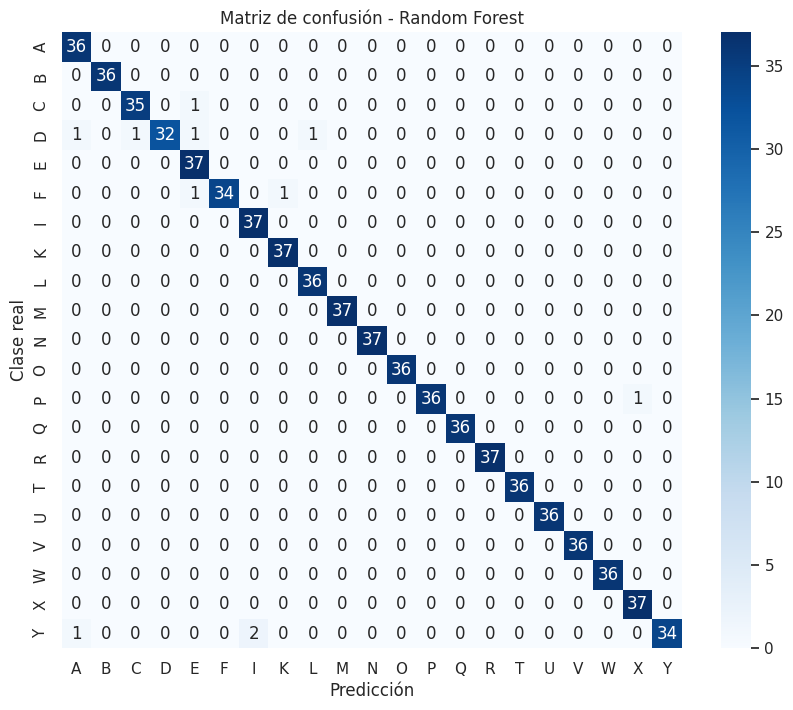

In [18]:
modelos_clasicos = {
    'SVM RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced'),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5)),
    ]),
}

modelos_clasicos_entrenados = {}

for nombre, modelo in modelos_clasicos.items():
    print(f'Entrenando {nombre}...')
    trained_model = clone(modelo)
    trained_model.fit(X_train_tabular, y_train)
    y_pred = trained_model.predict(X_test_tabular)

    modelos_clasicos_entrenados[nombre] = trained_model
    resultado = registrar_resultado(nombre, 'ML clásico + geometría', y_test, y_pred)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in resultado.items()})

mejor_clasico_nombre = max(
    [r for r in resultados_modelos if r['familia'] == 'ML clásico + geometría'],
    key=lambda r: r['macro_f1'],
)['modelo']
modelo_clasico_ganador = modelos_clasicos_entrenados[mejor_clasico_nombre]

mostrar_reporte(mejor_clasico_nombre, y_test, predicciones_test[mejor_clasico_nombre])


## 13. MLP sobre features geométricas

La MLP también usa la representación tabular enriquecida. Así se compara una red densa que recibe coordenadas, distancias y ángulos contra los modelos clásicos y contra la GCN.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,365 (99.08 KB)

 Trainable params: 25,109 (98.08 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3182 - loss: 2.4161 - val_accuracy: 0.3431 - val_loss: 2.6249
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6429 - loss: 1.2897 - val_accuracy: 0.6944 - val_loss: 2.0264
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7395 - loss: 0.9279 - val_accuracy: 0.8105 - val_loss: 1.4425
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7734 - loss: 0.7859 - val_accuracy: 0.8072 - val_loss: 1.0246
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8029 - loss: 0.6970 - val_accuracy: 0.8562 - val_loss: 0.6372
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8204 - loss: 0.6131 - val_accuracy: 0.8660 - val_loss: 0.5139
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8303 - loss: 0.5763 - val_accuracy: 0.8807 - val_loss: 0.3958
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8409 - loss: 0.5379 - val_accuracy: 0.8873 - v

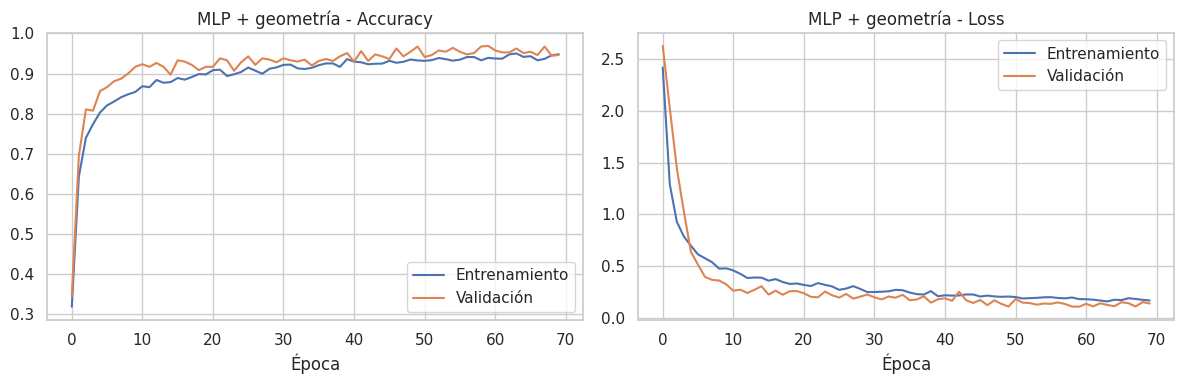

Reporte de clasificación: MLP + geometría
              precision    recall  f1-score   support

           A       0.92      1.00      0.96        36
           B       0.97      0.97      0.97        36
           C       1.00      0.83      0.91        36
           D       0.94      0.89      0.91        36
           E       0.95      0.97      0.96        37
           F       0.92      0.94      0.93        36
           I       0.95      0.95      0.95        37
           K       0.97      1.00      0.99        37
           L       0.97      0.97      0.97        36
           M       0.95      1.00      0.97        37
           N       1.00      0.95      0.97        37
           O       0.97      1.00      0.99        36
           P       1.00      0.97      0.99        37
           Q       0.92      1.00      0.96        36
           R       0.97      0.89      0.93        37
           T       0.97      0.89      0.93        36
           U       0.95      1.00      

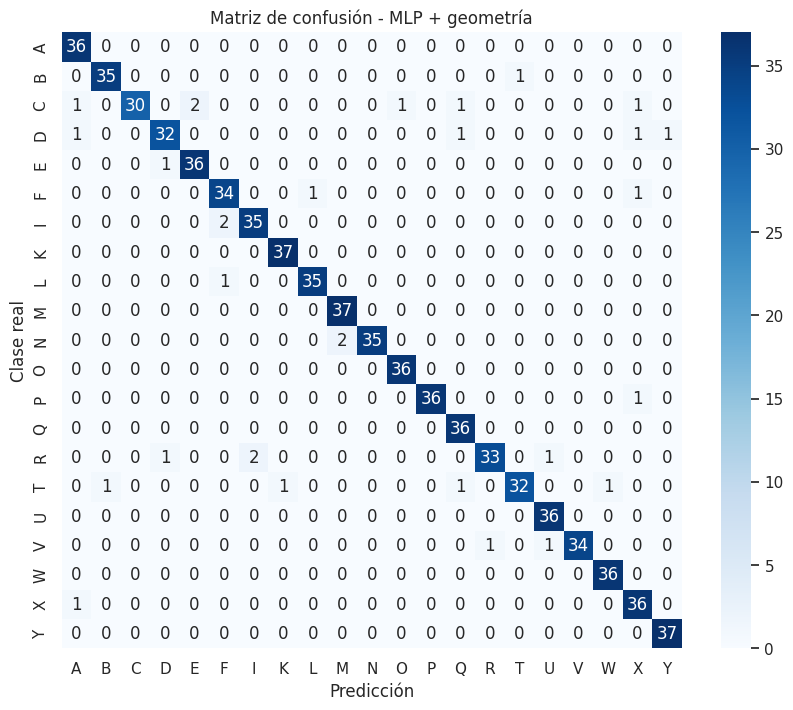

In [19]:
def construir_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.30),
        Dense(64, activation='relu'),
        Dropout(0.20),
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


modelo_mlp = construir_mlp(X_train_tabular.shape[1], num_classes)
modelo_mlp.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

historial_mlp = modelo_mlp.fit(
    X_train_tabular,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

historias_entrenamiento['MLP'] = historial_mlp.history

y_pred_mlp = np.argmax(modelo_mlp.predict(X_test_tabular, verbose=0), axis=1)
registrar_resultado('MLP + geometría', 'Red neuronal + geometría', y_test, y_pred_mlp)

plot_history(historial_mlp, 'MLP + geometría')
mostrar_reporte('MLP + geometría', y_test, y_pred_mlp)


## 14. GCN con PyTorch Geometric

La GCN recibe cada muestra como un grafo fijo de 21 nodos. Cada nodo contiene `(x, y, z)` y las aristas representan la anatomía de la mano.

La razón para probar GCN es que una letra suele depender de relaciones locales: flexión de un dedo, separación entre dedos, alineación de falanges y forma de la palma. Las capas GCN propagan información entre landmarks vecinos antes de clasificar la mano completa.

Importante: como los landmarks de MediaPipe tienen identidad fija, el nodo `4` siempre es la punta del pulgar y el nodo `8` siempre es la punta del índice. Por eso aquí **no usamos `global_mean_pool` como salida final**, porque promediar todos los nodos puede borrar diferencias críticas entre dedos. Después de las capas GCN convertimos el batch a tensor denso y hacemos `Flatten`, conservando el orden semántico de los 21 landmarks.


In [23]:
import torch
import torch.nn.functional as F
from itertools import combinations
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GraphNorm, BatchNorm
from torch_geometric.utils import to_dense_batch

TIP_INDICES_GCN = [4, 8, 12, 16, 20]
NEIGHBOR_TIP_EDGES = [(8, 12), (12, 16), (16, 20)]
NEIGHBOR_MCP_EDGES = [(5, 9), (9, 13), (13, 17)]
THUMB_INDEX_EDGES = [(4, 8), (1, 5)]

def build_adjacency(num_nodes, base_connections, extra_edges=None):
    edges = set()
    def add_edge(a, b):
        if 0 <= a < num_nodes and 0 <= b < num_nodes and a != b:
            edges.add(tuple(sorted((a, b))))
    for a, b in base_connections:
        add_edge(a, b)
    for a, b in (extra_edges or []):
        add_edge(a, b)
    return sorted(edges)

def build_edge_index(edges_undirected):
    directed = []
    for i, j in edges_undirected:
        directed.append((i, j))
        directed.append((j, i))
    edge_index = torch.tensor(directed, dtype=torch.long).t().contiguous()
    return edge_index, directed

EXTRA_TIP_EDGES = list(combinations(TIP_INDICES_GCN, 2))
EXTRA_EDGES = EXTRA_TIP_EDGES + NEIGHBOR_TIP_EDGES + NEIGHBOR_MCP_EDGES + THUMB_INDEX_EDGES
GCN_EDGES = build_adjacency(21, HAND_CONNECTIONS, EXTRA_EDGES)
edge_index, _ = build_edge_index(GCN_EDGES)

_, _node_feat_example = build_features(np.zeros((21, 3), dtype=np.float32), HAND_CONNECTIONS)
NODE_FEATURE_DIM = _node_feat_example.shape[1]

def make_graph_dataset_v2(X_graph_values, y_values, edges, base_connections, noise_sigma=0.0):
    data_list = []
    for x, y in zip(X_graph_values, y_values):
        coords = x.astype(np.float32)
        if noise_sigma > 0:
            coords = coords + np.random.normal(0, noise_sigma, coords.shape).astype(np.float32)
        coords_norm, node_features = build_features(coords, edges, base_connections)

        edge_feats = []
        for i, j in edges:
            dist = np.linalg.norm(coords_norm[i] - coords_norm[j])
            edge_feats.append([dist])
        ef = torch.tensor(edge_feats + edge_feats, dtype=torch.float32)
        data_list.append(Data(
            x=torch.tensor(node_features, dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=ef,
            y=torch.tensor(int(y), dtype=torch.long),
        ))
    return data_list

train_graph_idx, val_graph_idx = train_test_split(
    np.arange(len(X_train_graph)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
 )

# Generación de datasets usando features enriquecidas y grafo extendido
graph_train_data = make_graph_dataset_v2(X_train_graph[train_graph_idx], y_train[train_graph_idx], GCN_EDGES, HAND_CONNECTIONS, noise_sigma=0.005)
graph_val_data = make_graph_dataset_v2(X_train_graph[val_graph_idx], y_train[val_graph_idx], GCN_EDGES, HAND_CONNECTIONS)
graph_test_data = make_graph_dataset_v2(X_test_graph, y_test, GCN_EDGES, HAND_CONNECTIONS)

train_loader = DataLoader(graph_train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(graph_val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(graph_test_data, batch_size=64, shuffle=False)

class HandGCNv2(torch.nn.Module):
    def __init__(self, in_channels, hidden_dims=64, num_layers=3, num_classes=21, num_nodes=21, dropout=0.3):
        super().__init__()
        if isinstance(hidden_dims, int):
            hidden_dims = [hidden_dims] * num_layers
        if len(hidden_dims) != num_layers:
            raise ValueError('hidden_dims debe coincidir con num_layers')

        self.proj = torch.nn.Linear(in_channels, hidden_dims[0])
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        self.num_nodes = num_nodes
        self.dropout = dropout

        for idx in range(num_layers):
            in_dim = hidden_dims[idx - 1] if idx > 0 else hidden_dims[0]
            out_dim = hidden_dims[idx]
            self.convs.append(GCNConv(in_dim, out_dim))
            self.norms.append(GraphNorm(out_dim)) # Changed BatchNorm to GraphNorm

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(num_nodes * hidden_dims[-1], 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.proj(x))
        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index)
            h = norm(h, batch)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = x + h if x.shape == h.shape else h
        x_dense, _ = to_dense_batch(x, batch, max_num_nodes=self.num_nodes)
        return self.classifier(x_dense.reshape(x_dense.size(0), -1))

def build_loss_fn(class_weights=None, label_smoothing=0.1, device='cpu'):
    weight_tensor = class_weights.to(device) if class_weights is not None else None
    return torch.nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=label_smoothing)

def run_epoch(model, loader, optimizer=None, device='cpu', loss_fn=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, y_true, y_pred = 0.0, [], []
    loss_fn = loss_fn or build_loss_fn(device=device)
    for batch in loader:
        batch = batch.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(batch)
        loss = loss_fn(logits, batch.y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        y_true.extend(batch.y.detach().cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy())
    return total_loss / len(loader.dataset), accuracy_score(y_true, y_pred), np.array(y_true), np.array(y_pred)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GCN_LAYERS = 3
GCN_HIDDEN_DIMS = 32
GCN_DROPOUT = 0.3
modelo_gcn = HandGCNv2(
    in_channels=NODE_FEATURE_DIM,
    hidden_dims=GCN_HIDDEN_DIMS,
    num_layers=GCN_LAYERS,
    num_classes=num_classes,
    dropout=GCN_DROPOUT,
).to(device)
optimizer = torch.optim.Adam(modelo_gcn.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn_gcn = build_loss_fn(label_smoothing=0.1, device=device)

Epoch 001 | loss=2.5123 acc=0.2683 | val_loss=1.6213 val_acc=0.6160
Epoch 010 | loss=0.9872 acc=0.8789 | val_loss=0.8584 val_acc=0.9281
Epoch 020 | loss=0.8432 acc=0.9391 | val_loss=0.7457 val_acc=0.9608
Epoch 030 | loss=0.7800 acc=0.9603 | val_loss=0.7139 val_acc=0.9788
Epoch 040 | loss=0.7399 acc=0.9779 | val_loss=0.6971 val_acc=0.9788
Epoch 050 | loss=0.7221 acc=0.9832 | val_loss=0.6902 val_acc=0.9771
Epoch 060 | loss=0.7112 acc=0.9791 | val_loss=0.6707 val_acc=0.9788
Epoch 070 | loss=0.6967 acc=0.9853 | val_loss=0.6763 val_acc=0.9788
Epoch 080 | loss=0.6874 acc=0.9877 | val_loss=0.6606 val_acc=0.9853
Epoch 090 | loss=0.6809 acc=0.9910 | val_loss=0.6645 val_acc=0.9837
Epoch 100 | loss=0.6804 acc=0.9840 | val_loss=0.6666 val_acc=0.9837
Epoch 110 | loss=0.6728 acc=0.9914 | val_loss=0.6664 val_acc=0.9820
Early stopping en epoch 110


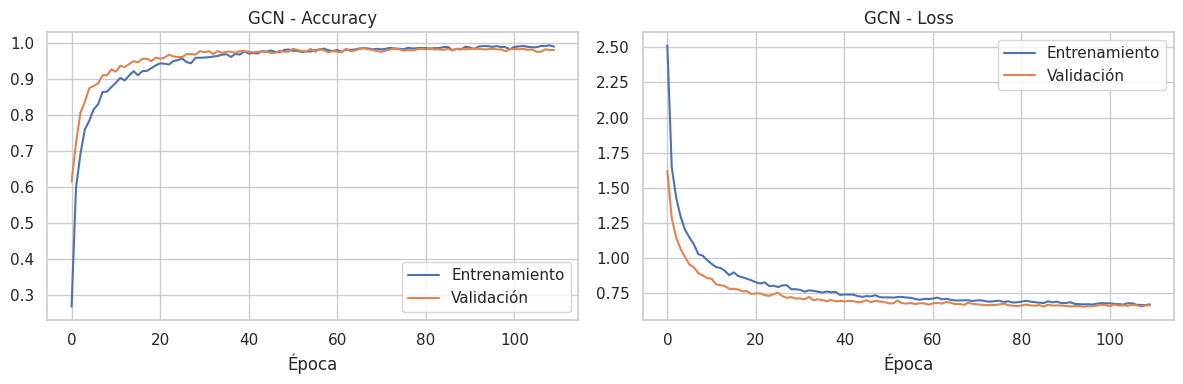

Reporte de clasificación: GCN PyTorch Geometric
              precision    recall  f1-score   support

           A       0.88      1.00      0.94        36
           B       1.00      1.00      1.00        36
           C       0.89      0.94      0.92        36
           D       1.00      0.92      0.96        36
           E       0.95      1.00      0.97        37
           F       0.95      0.97      0.96        36
           I       1.00      0.95      0.97        37
           K       1.00      1.00      1.00        37
           L       1.00      1.00      1.00        36
           M       1.00      0.92      0.96        37
           N       0.95      1.00      0.97        37
           O       1.00      0.97      0.99        36
           P       0.97      0.97      0.97        37
           Q       0.95      0.97      0.96        36
           R       1.00      0.97      0.99        37
           T       1.00      1.00      1.00        36
           U       1.00      1.00

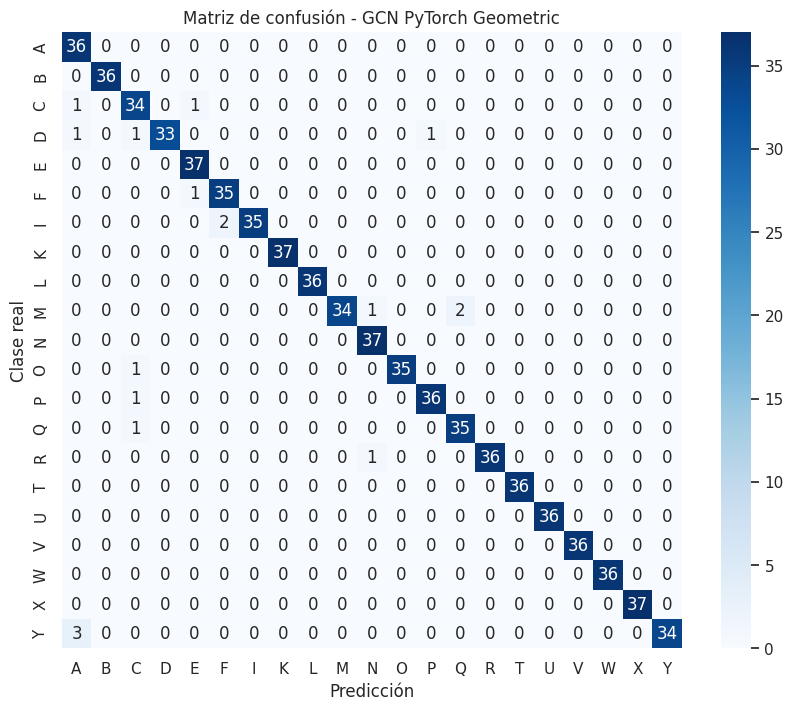

In [24]:

best_val_loss = float('inf')
best_state = None
patience = 15
patience_counter = 0
history_gcn = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(1, 151):
    train_loss, train_acc, _, _ = run_epoch(modelo_gcn, train_loader, optimizer, device, loss_fn=loss_fn_gcn)
    val_loss, val_acc, _, _ = run_epoch(modelo_gcn, val_loader, None, device, loss_fn=loss_fn_gcn)

    history_gcn['loss'].append(train_loss)
    history_gcn['accuracy'].append(train_acc)
    history_gcn['val_loss'].append(val_loss)
    history_gcn['val_accuracy'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in modelo_gcn.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping en epoch {epoch}')
        break

if best_state is not None:
    modelo_gcn.load_state_dict(best_state)

historias_entrenamiento['GCN'] = history_gcn

test_loss, test_acc, y_true_gcn, y_pred_gcn = run_epoch(modelo_gcn, test_loader, None, device, loss_fn=loss_fn_gcn)
registrar_resultado('GCN PyTorch Geometric', 'GCN', y_true_gcn, y_pred_gcn)

plot_history(history_gcn, 'GCN')
mostrar_reporte('GCN PyTorch Geometric', y_true_gcn, y_pred_gcn)


### 14.1. Mejora de la GCN: HandGAT (Graph Attention Network)

Implementamos una versión con capas de atención y pesos de clase para mejorar la discriminación entre señas visualmente similares.

In [25]:
from torch_geometric.nn import GATConv, GraphNorm
from sklearn.utils.class_weight import compute_class_weight

# Pesos de clase
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

class HandGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, num_nodes=21, heads=4, dropout=0.3):
        super().__init__()
        self.num_nodes = num_nodes
        self.dropout = dropout

        # Capa de Atencion 1 con edge_dim para procesar distancias euclidianas
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        self.norm1 = GraphNorm(hidden_channels * heads)

        # Capa de Atencion 2
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels * 2, heads=1, concat=False, dropout=dropout, edge_dim=1)
        self.norm2 = GraphNorm(hidden_channels * 2)

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(num_nodes * hidden_channels * 2, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        # Pasamos edge_attr a las capas GAT
        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = self.norm1(x, batch)

        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = self.norm2(x, batch)

        x_dense, _ = to_dense_batch(x, batch, max_num_nodes=self.num_nodes)
        x_flat = x_dense.reshape(x_dense.size(0), -1)
        return self.classifier(x_flat)

# Inicializar modelo mejorado con soporte para edge_attr
modelo_gat = HandGAT(in_channels=NODE_FEATURE_DIM, hidden_channels=32, num_classes=num_classes).to(device)
optimizer_gat = torch.optim.Adam(modelo_gat.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_gat, mode='min', factor=0.5, patience=5)
loss_fn_gat = build_loss_fn(class_weights, label_smoothing=0.1, device=device)

print("Modelo HandGAT inicializado. Ahora consume distancias euclidianas (edge_dim=1) en las capas de atencion.")


Modelo HandGAT inicializado. Ahora consume distancias euclidianas (edge_dim=1) en las capas de atencion.


In [26]:
#@title **Run HandGAT**
def run_epoch_weighted(model, loader, optimizer=None, device='cpu', loss_fn=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, y_true, y_pred = 0.0, [], []
    loss_fn = loss_fn or build_loss_fn(device=device)

    for batch in loader:
        batch = batch.to(device)
        if is_train:
            optimizer.zero_grad()

        logits = model(batch)
        loss = loss_fn(logits, batch.y)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(y_true, y_pred)

# Entrenamiento rapido del modelo mejorado
for epoch in range(1, 101):
    t_loss, t_acc = run_epoch_weighted(modelo_gat, train_loader, optimizer_gat, device, loss_fn=loss_fn_gat)
    v_loss, v_acc = run_epoch_weighted(modelo_gat, val_loader, None, device, loss_fn=loss_fn_gat)
    scheduler.step(v_loss)
    if epoch % 10 == 0:
        print(f'GAT Epoch {epoch:02d} | Loss: {t_loss:.3f} | Val Acc: {v_acc:.3f}')

# Registrar resultado para comparar
_, _, y_t, y_p = run_epoch(modelo_gat, test_loader, None, device, loss_fn=loss_fn_gat)
registrar_resultado('GAT Mejorada', 'GCN', y_t, y_p)
print("Modelo GAT entrenado y registrado.")


GAT Epoch 10 | Loss: 1.004 | Val Acc: 0.943
GAT Epoch 20 | Loss: 0.890 | Val Acc: 0.956
GAT Epoch 30 | Loss: 0.840 | Val Acc: 0.975
GAT Epoch 40 | Loss: 0.788 | Val Acc: 0.974
GAT Epoch 50 | Loss: 0.768 | Val Acc: 0.979
GAT Epoch 60 | Loss: 0.742 | Val Acc: 0.980
GAT Epoch 70 | Loss: 0.740 | Val Acc: 0.984
GAT Epoch 80 | Loss: 0.729 | Val Acc: 0.984
GAT Epoch 90 | Loss: 0.718 | Val Acc: 0.984
GAT Epoch 100 | Loss: 0.721 | Val Acc: 0.984
Modelo GAT entrenado y registrado.


#### Re-generar DataLoaders con Aumentación

Aplicamos la aumentación solo al set de entrenamiento.

In [27]:
def augment_landmarks(
    coords,
    sigma_noise=0.005,
    max_rot_deg=15.0,
    scale_range=(0.9, 1.1),
    p_dropout=0.08,
 ):
    """Aumentacion sobre landmarks normalizados (21, 3)."""
    x_aug = coords.astype(np.float32).copy()

    # 1. Ruido gaussiano
    if sigma_noise > 0:
        x_aug += np.random.normal(0, sigma_noise, x_aug.shape).astype(np.float32)

    # 2. Rotacion aleatoria en XY
    angle = np.radians(np.random.uniform(-max_rot_deg, max_rot_deg))
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    x_aug = (R @ x_aug.T).T

    # 3. Escala aleatoria
    scale = np.random.uniform(scale_range[0], scale_range[1])
    x_aug *= scale

    # 4. Dropout de nodos (mantener muneca)
    if p_dropout > 0:
        drop_mask = np.random.rand(x_aug.shape[0]) < p_dropout
        drop_mask[0] = False
        x_aug[drop_mask] = 0.0

    # Re-normalizar y re-alinear
    x_aug = normalize_landmarks(x_aug)
    return x_aug

def make_graph_dataset_augmented(X_graph_values, y_values, edges, base_connections, augment=False, noise_sigma=0.0):
    data_list = []
    for x, y in zip(X_graph_values, y_values):
        coords = x.astype(np.float32)
        if noise_sigma > 0:
            coords = coords + np.random.normal(0, noise_sigma, coords.shape).astype(np.float32)
        if augment:
            coords = augment_landmarks(coords)

        coords_norm, node_features = build_features(coords, edges, base_connections)
        edge_feats = []
        for i, j in edges:
            dist = np.linalg.norm(coords_norm[i] - coords_norm[j])
            edge_feats.append([dist])
        ef = torch.tensor(edge_feats + edge_feats, dtype=torch.float32)
        data_list.append(Data(
            x=torch.tensor(node_features, dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=ef,
            y=torch.tensor(int(y), dtype=torch.long),
        ))
    return data_list


### 14.2. Aumentación de Datos para Robustez

Definimos transformaciones aleatorias que simulan las variaciones de la cámara (ruido de MediaPipe, rotación de la mano, escala y lateralidad).

In [28]:
graph_train_data_aug = make_graph_dataset_augmented(
    X_train_graph[train_graph_idx],
    y_train[train_graph_idx],
    GCN_EDGES,
    HAND_CONNECTIONS,
    augment=True,
    noise_sigma=0.005,
 )
graph_val_data_no_aug = make_graph_dataset_augmented(
    X_train_graph[val_graph_idx],
    y_train[val_graph_idx],
    GCN_EDGES,
    HAND_CONNECTIONS,
    augment=False,
 )

train_loader_aug = DataLoader(graph_train_data_aug, batch_size=32, shuffle=True)
val_loader_no_aug = DataLoader(graph_val_data_no_aug, batch_size=64, shuffle=False)

# Inicializar un nuevo modelo HandGAT para entrenar con aumentacion
modelo_gat_robust = HandGAT(in_channels=NODE_FEATURE_DIM, hidden_channels=32, num_classes=num_classes).to(device)
optimizer_robust = torch.optim.Adam(modelo_gat_robust.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_robust = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_robust, mode='min', factor=0.5, patience=5)
loss_fn_gat = build_loss_fn(class_weights, label_smoothing=0.1, device=device)

print("Entrenando modelo HandGAT Robusto (con Aumentacion)... Solo tomara unos segundos.")

for epoch in range(1, 101):
    t_loss, t_acc = run_epoch_weighted(modelo_gat_robust, train_loader_aug, optimizer_robust, device, loss_fn=loss_fn_gat)
    v_loss, v_acc = run_epoch_weighted(modelo_gat_robust, val_loader_no_aug, None, device, loss_fn=loss_fn_gat)
    scheduler_robust.step(v_loss)
    if epoch % 20 == 0:
        print(f'Robust GAT Epoch {epoch:02d} | Loss: {t_loss:.3f} | Val Acc: {v_acc:.3f}')

# Registrar resultado
_, _, y_t_rob, y_p_rob = run_epoch(modelo_gat_robust, test_loader, None, device, loss_fn=loss_fn_gat)
registrar_resultado('HandGAT Robusto (Augment)', 'GCN', y_t_rob, y_p_rob)
print("\nModelo Robusto entrenado y registrado para comparacion.")


Entrenando modelo HandGAT Robusto (con Aumentacion)... Solo tomara unos segundos.
Robust GAT Epoch 20 | Loss: 1.010 | Val Acc: 0.941
Robust GAT Epoch 40 | Loss: 0.899 | Val Acc: 0.954
Robust GAT Epoch 60 | Loss: 0.815 | Val Acc: 0.966
Robust GAT Epoch 80 | Loss: 0.777 | Val Acc: 0.967
Robust GAT Epoch 100 | Loss: 0.751 | Val Acc: 0.967

Modelo Robusto entrenado y registrado para comparacion.


## 15. Comparación visual de resultados

Las siguientes gráficas ayudan a defender la elección del modelo:

- **Barras de accuracy y macro-F1**: comparación directa entre familias.
- **F1 por clase**: muestra si el modelo mejora de forma general o solo en algunas letras.
- **Matriz de confusión del mejor modelo**: identifica qué letras se confunden y si el error tiene sentido visual.


,modelo,familia,accuracy,precision_macro,recall_macro,macro_f1,weighted_f1
1,Random Forest,ML clásico + geometría,0.986,0.986,0.986,0.986,0.986
5,GAT Mejorada,GCN,0.983,0.984,0.983,0.983,0.983
4,GCN PyTorch Geometric,GCN,0.976,0.978,0.977,0.977,0.977
0,SVM RBF,ML clásico + geometría,0.967,0.969,0.967,0.967,0.967
6,HandGAT Robusto (Augment),GCN,0.966,0.968,0.966,0.966,0.966
3,MLP + geometría,Red neuronal + geometría,0.959,0.961,0.959,0.959,0.959
2,KNN,ML clásico + geometría,0.944,0.945,0.944,0.943,0.943


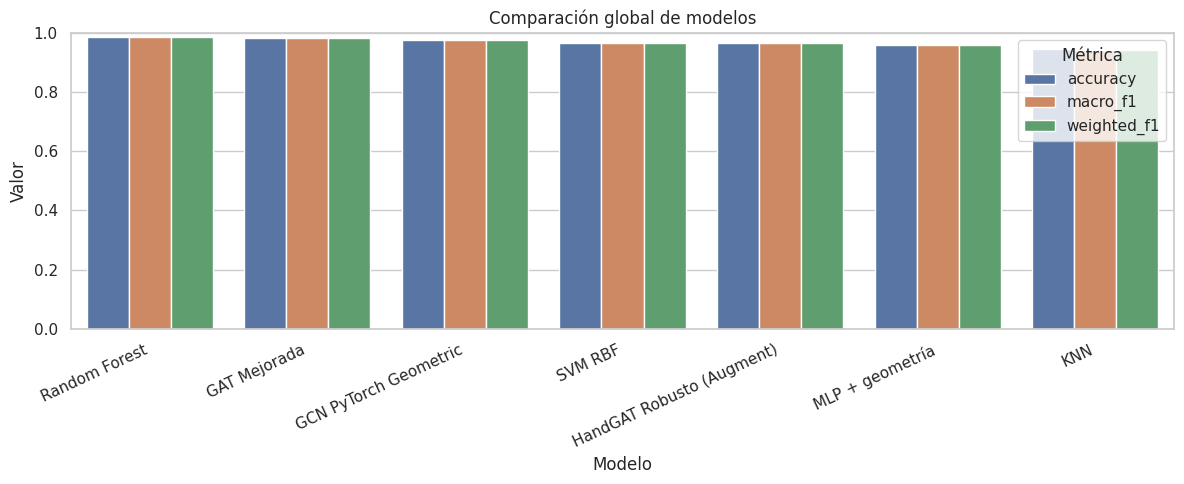

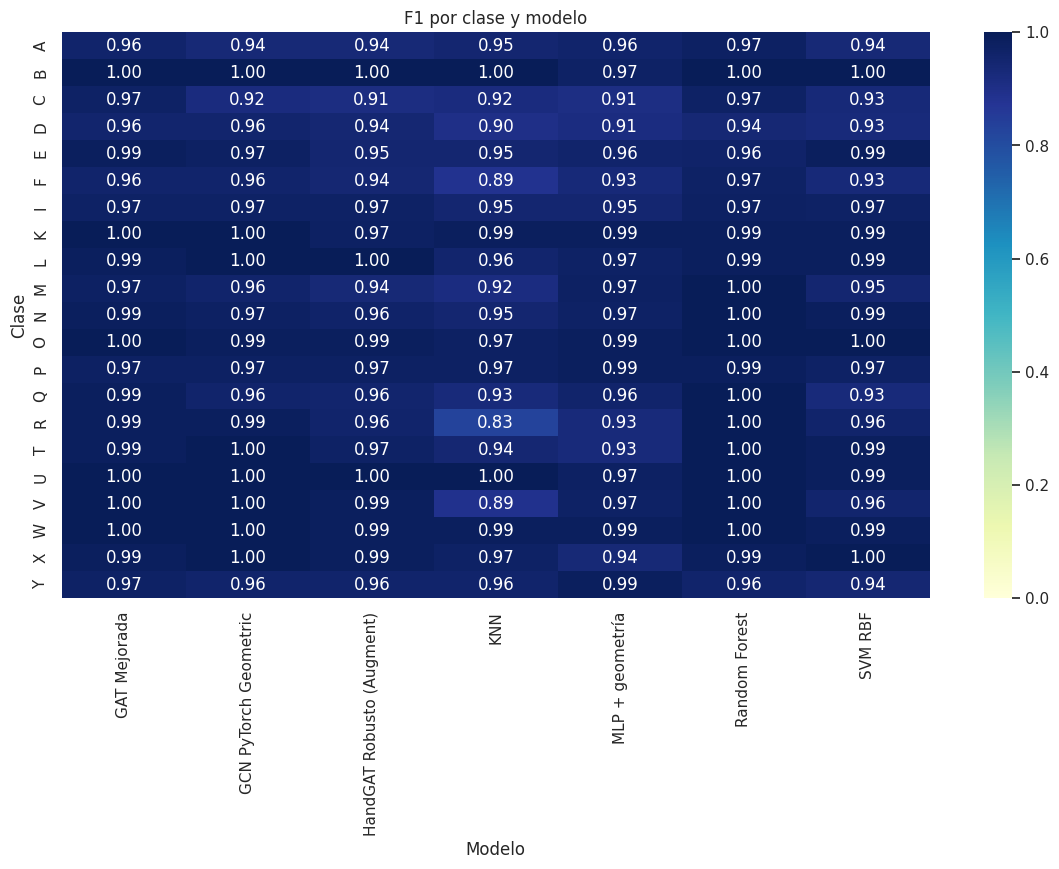

Mejor modelo por macro-F1: Random Forest
Reporte de clasificación: Random Forest
              precision    recall  f1-score   support

           A       0.95      1.00      0.97        36
           B       1.00      1.00      1.00        36
           C       0.97      0.97      0.97        36
           D       1.00      0.89      0.94        36
           E       0.93      1.00      0.96        37
           F       1.00      0.94      0.97        36
           I       0.95      1.00      0.97        37
           K       0.97      1.00      0.99        37
           L       0.97      1.00      0.99        36
           M       1.00      1.00      1.00        37
           N       1.00      1.00      1.00        37
           O       1.00      1.00      1.00        36
           P       1.00      0.97      0.99        37
           Q       1.00      1.00      1.00        36
           R       1.00      1.00      1.00        37
           T       1.00      1.00      1.00        36


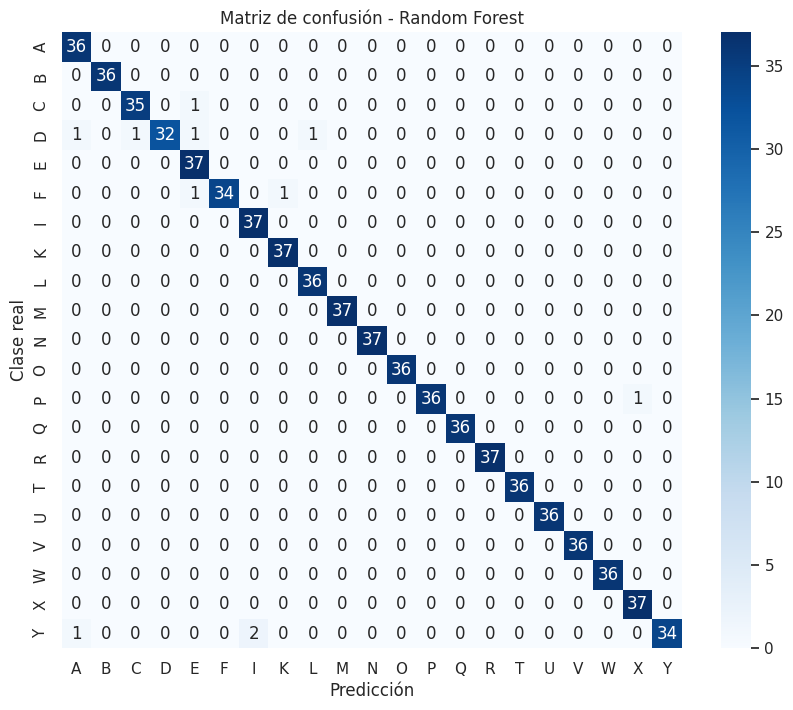

In [29]:
resultados_df = pd.DataFrame(resultados_modelos).sort_values('macro_f1', ascending=False)
display(resultados_df.style.format({
    'accuracy': '{:.3f}',
    'precision_macro': '{:.3f}',
    'recall_macro': '{:.3f}',
    'macro_f1': '{:.3f}',
    'weighted_f1': '{:.3f}',
}))

plot_df = resultados_df.melt(
    id_vars=['modelo', 'familia'],
    value_vars=['accuracy', 'macro_f1', 'weighted_f1'],
    var_name='métrica',
    value_name='valor',
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='modelo', y='valor', hue='métrica')
plt.title('Comparación global de modelos')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.ylim(0, 1.0)
plt.xticks(rotation=25, ha='right')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

# F1 por clase para comparar si la mejora es homogénea.
f1_rows = []
for model_name, report in reportes_test.items():
    for class_name in class_names:
        f1_rows.append({
            'modelo': model_name,
            'clase': class_name,
            'f1': report[class_name]['f1-score'],
        })

f1_df = pd.DataFrame(f1_rows)
f1_pivot = f1_df.pivot(index='clase', columns='modelo', values='f1')

plt.figure(figsize=(max(10, len(f1_pivot.columns) * 2), max(6, len(f1_pivot) * 0.35)))
sns.heatmap(f1_pivot, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('F1 por clase y modelo')
plt.xlabel('Modelo')
plt.ylabel('Clase')
plt.show()

best_model_name = resultados_df.iloc[0]['modelo']
print('Mejor modelo por macro-F1:', best_model_name)
mostrar_reporte(best_model_name, y_test, predicciones_test[best_model_name])

## 16. Lectura de resultados

Para concluir, conviene revisar tres preguntas:

1. **¿Las distancias y ángulos mejoran las letras difíciles?** Revisa especialmente clases como `Q`, `T`, `V` y `W`, no solo el accuracy global.
2. **¿La GCN supera o se acerca a los modelos tabulares enriquecidos?** Si no lo hace, puede indicar que para imágenes estáticas las features geométricas explícitas son más fáciles de aprender que una topología de grafo entrenada con pocos datos.
3. **¿La mejora aparece en macro-F1 y no solo en accuracy?** Esto evita que la conclusión dependa de clases dominantes.

Una GCN puede ayudar porque no trata los 63 valores como una lista sin estructura. En cada capa, cada landmark combina su información con la de sus vecinos anatómicos. Sin embargo, las distancias y los ángulos codifican directamente separación y flexión de dedos, que son señales muy relevantes en un alfabeto estático.

## 17. Guardar modelos y metadatos para inferencia

Esta celda guarda los artefactos necesarios para usar el mejor modelo luego en una aplicación:

- Encoder de etiquetas.
- Columnas/features esperadas para coordenadas y para la representación tabular enriquecida.
- Conexiones del grafo.
- Modelos clásicos entrenados.
- MLP en formato Keras.
- GCN en formato `state_dict` de PyTorch.
- Tabla de resultados y metadatos del experimento.

En inferencia se debe repetir exactamente la misma normalización: landmarks centrados en muñeca y escalados por envergadura.

In [30]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Guardar modelos clasicos
if 'modelos_clasicos_entrenados' in globals():
    joblib.dump(modelos_clasicos_entrenados, ARTIFACTS_DIR / 'modelos_clasicos.joblib')
    joblib.dump(modelo_clasico_ganador, ARTIFACTS_DIR / 'mejor_modelo_clasico.joblib')

# Guardar MLP
if 'modelo_mlp' in globals():
    modelo_mlp.save(str(ARTIFACTS_DIR / 'modelo_mlp.keras'))

# Guardar GCN Original
if 'modelo_gcn' in globals():
    torch.save({
        'state_dict': modelo_gcn.cpu().state_dict(),
        'model_class': 'HandGCN',
        'in_channels': int(NODE_FEATURE_DIM),
        'hidden_channels': GCN_HIDDEN_DIMS,
        'num_classes': int(num_classes),
        'num_nodes': 21,
        'dropout': GCN_DROPOUT,
        'edge_index': edge_index.cpu(),
        'hand_connections': GCN_EDGES,
        'class_names': class_names.tolist(),
    }, ARTIFACTS_DIR / 'modelo_gcn_pyg.pt')
    modelo_gcn.to(device)

# Guardar GAT Mejorada
if 'modelo_gat' in globals():
    torch.save({
        'state_dict': modelo_gat.cpu().state_dict(),
        'model_class': 'HandGAT',
        'in_channels': int(NODE_FEATURE_DIM),
        'hidden_channels': 32,
        'num_classes': int(num_classes),
        'num_nodes': 21,
        'edge_index': edge_index.cpu(),
        'hand_connections': GCN_EDGES,
        'class_names': class_names.tolist(),
    }, ARTIFACTS_DIR / 'modelo_gat_mejorado.pt')
    modelo_gat.to(device)

# Guardar HandGAT Robusto (Aumentado)
if 'modelo_gat_robust' in globals():
    torch.save({
        'state_dict': modelo_gat_robust.cpu().state_dict(),
        'model_class': 'HandGAT',
        'in_channels': int(NODE_FEATURE_DIM),
        'hidden_channels': 32,
        'num_classes': int(num_classes),
        'num_nodes': 21,
        'edge_index': edge_index.cpu(),
        'hand_connections': GCN_EDGES,
        'class_names': class_names.tolist(),
    }, ARTIFACTS_DIR / 'modelo_gat_robusto.pt')
    modelo_gat_robust.to(device)

# Guardar encoder, resultados y contrato de entrada
joblib.dump(encoder, ARTIFACTS_DIR / 'label_encoder.joblib')

resultados_df.to_csv(ARTIFACTS_DIR / 'comparacion_modelos.csv', index=False)

metadata = {
    'random_state': RANDOM_STATE,
    'normalized_dataset_path': str(NORMALIZED_DATASET_PATH),
    'feature_columns': feature_columns,
    'tabular_feature_strategy': TABULAR_FEATURE_STRATEGY if 'TABULAR_FEATURE_STRATEGY' in globals() else 'landmarks_63_only',
    'tabular_feature_names': tabular_feature_names if 'tabular_feature_names' in globals() else feature_columns,
    'class_names': class_names.tolist(),
    'num_landmarks': 21,
    'features_per_landmark': 3,
    'flat_input_shape': [63],
    'tabular_input_shape': [len(tabular_feature_names)] if 'tabular_feature_names' in globals() else [63],
    'graph_input_shape': [21, int(NODE_FEATURE_DIM)],
    'normalization': 'Restar landmark 0 (muneca), escalar por distancia maxima y alinear el vector 0-9 al eje X.',
    'hand_connections': GCN_EDGES,
    'best_model_by_macro_f1': best_model_name if 'best_model_name' in globals() else None,
}

with (ARTIFACTS_DIR / 'metadata_inferencia.json').open('w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Artefactos guardados en:', ARTIFACTS_DIR.resolve())
print('\nArchivos:')
for path in sorted(ARTIFACTS_DIR.iterdir()):
    print('-', path.name)


Artefactos guardados en: /content/model_artifacts_kaggle

Archivos:
- comparacion_modelos.csv
- label_encoder.joblib
- mejor_modelo_clasico.joblib
- metadata_inferencia.json
- modelo_gat_mejorado.pt
- modelo_gat_robusto.pt
- modelo_gcn_pyg.pt
- modelo_mlp.keras
- modelos_clasicos.joblib


## 18. Aplicación de inferencia en video

Esta fase usa los artefactos guardados en la sección anterior para hacer inferencia sobre frames de video. La aplicación mantiene exactamente el mismo contrato del entrenamiento:

1. Capturar un frame desde cámara o archivo de video.
2. Detectar una mano con MediaPipe Hands.
3. Normalizar los 21 landmarks: centrar en muñeca y escalar por la máxima distancia a la muñeca.
4. Construir la entrada del modelo: vector plano `(63,)` para modelos clásicos/MLP o grafo `(21, 3)` para GCN.
5. Predecir la letra.
6. Aplicar estabilización temporal para reducir cambios bruscos entre frames.

Como el proyecto trabaja con señas estáticas, la predicción se hace frame a frame. El búfer temporal no modela una seña dinámica; solo suaviza la salida visual para que la interfaz sea más estable.

### 18.1. Cargar artefactos y seleccionar modelo

La inferencia no debe depender de variables temporales del entrenamiento. Por eso se cargan desde `model_artifacts/` el encoder, los metadatos y el modelo seleccionado.

Por defecto, `MODELO_INFERENCIA = 'auto'` intenta usar el mejor modelo según `macro-F1`. También puedes forzar un modelo escribiendo, por ejemplo, `'Random Forest'`, `'SVM RBF'`, `'KNN'`, `'MLP'` o `'GCN PyTorch Geometric'`.


In [31]:
from collections import Counter, deque
from pathlib import Path
import json
import random
import time

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
import tensorflow as tf

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GraphNorm
    from torch_geometric.utils import to_dense_batch
except ImportError:
    torch = None
    Data = None
    GCNConv = None
    to_dense_batch = None

INFERENCE_ARTIFACTS_DIR = Path('model_artifacts_kaggle')
MODELO_INFERENCIA = 'auto'  # 'auto', 'Random Forest', 'SVM RBF', 'KNN', 'MLP', 'GCN PyTorch Geometric'

def cargar_metadata_inferencia(artifacts_dir=INFERENCE_ARTIFACTS_DIR):
    metadata_path = artifacts_dir / 'metadata_inferencia.json'
    encoder_path = artifacts_dir / 'label_encoder.joblib'

    if not metadata_path.exists():
        raise FileNotFoundError(f'No se encontró {metadata_path}.')
    if not encoder_path.exists():
        raise FileNotFoundError(f'No se encontró {encoder_path}.')

    with metadata_path.open('r', encoding='utf-8') as f:
        metadata = json.load(f)

    encoder = joblib.load(encoder_path)
    class_names = np.array(metadata.get('class_names', list(encoder.classes_)))
    hand_connections = [tuple(edge) for edge in metadata.get('hand_connections', HAND_CONNECTIONS)]

    return metadata, encoder, class_names, hand_connections

def build_edge_index_inferencia(connections):
    if torch is None: return None
    edges = []
    for i, j in connections:
        edges.append((i, j))
        edges.append((j, i))
    return torch.tensor(edges, dtype=torch.long).t().contiguous()

class HandGCNInference(torch.nn.Module if torch is not None else object):
    def __init__(self, in_channels, hidden_dims=64, num_layers=3, num_classes=21, num_nodes=21, dropout=0.3):
        super().__init__()
        if isinstance(hidden_dims, int):
            hidden_dims = [hidden_dims] * num_layers
        if len(hidden_dims) != num_layers:
            raise ValueError('hidden_dims debe coincidir con num_layers')

        self.proj = torch.nn.Linear(in_channels, hidden_dims[0])
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        self.num_nodes = num_nodes
        self.dropout = dropout

        for idx in range(num_layers):
            in_dim = hidden_dims[idx - 1] if idx > 0 else hidden_dims[0]
            out_dim = hidden_dims[idx]
            self.convs.append(GCNConv(in_dim, out_dim))
            self.norms.append(GraphNorm(out_dim))

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(num_nodes * hidden_dims[-1], 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.proj(x))
        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index)
            h = norm(h, batch)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = x + h if x.shape == h.shape else h
        x_dense, _ = to_dense_batch(x, batch, max_num_nodes=self.num_nodes)
        return self.classifier(x_dense.reshape(x_dense.size(0), -1))

def cargar_modelo_inferencia(model_name='auto', artifacts_dir=INFERENCE_ARTIFACTS_DIR):
    metadata, encoder, class_names, hand_connections = cargar_metadata_inferencia(artifacts_dir)
    requested_name = metadata.get('best_model_by_macro_f1') if model_name == 'auto' else model_name
    requested_name = requested_name or 'mejor_modelo_clasico'
    model_type = 'gcn' if 'gcn' in requested_name.lower() else ('mlp' if 'mlp' in requested_name.lower() else 'classic')

    package = {'name': requested_name, 'type': model_type, 'metadata': metadata, 'encoder': encoder, 'class_names': class_names, 'hand_connections': hand_connections, 'device': None, 'edge_index': None}

    if model_type == 'gcn':
        gcn_path = artifacts_dir / 'modelo_gcn_pyg.pt'
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        checkpoint = torch.load(gcn_path, map_location=device)
        model = HandGCNInference(
            in_channels=checkpoint.get('in_channels', 3),
            hidden_dims=checkpoint.get('hidden_channels', 32),
            num_layers=checkpoint.get('num_layers', 3),
            num_classes=checkpoint.get('num_classes', len(class_names)),
            dropout=checkpoint.get('dropout', 0.3)
        ).to(device)
        model.load_state_dict(checkpoint['state_dict'])
        model.eval()
        package.update({'model': model, 'device': device, 'edge_index': checkpoint.get('edge_index').to(device)})
        return package

    if model_type == 'mlp':
        package['model'] = tf.keras.models.load_model(str(artifacts_dir / 'modelo_mlp.keras'))
        return package

    package['model'] = joblib.load(artifacts_dir / 'mejor_modelo_clasico.joblib')
    return package

paquete_modelo = cargar_modelo_inferencia(MODELO_INFERENCIA)
print('Modelo cargado:', paquete_modelo['name'])

Modelo cargado: Random Forest


### 18.2. Extracción y normalización por frame

Esta celda replica el preprocesamiento usado durante el entrenamiento. La función principal recibe un frame BGR de OpenCV, detecta la mano y devuelve dos representaciones:

- `flat`: vector `(1, 63)` para modelos clásicos y MLP.
- `graph`: matriz `(21, 3)` para GCN.

Si MediaPipe no detecta mano, la función devuelve `None` y la aplicación conserva la última predicción estable o muestra estado de espera.


In [32]:
def crear_detector_inferencia(model_path=MEDIAPIPE_MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f'No se encontró el modelo MediaPipe: {model_path}')

    base_options = mp_python.BaseOptions(model_asset_path=str(model_path))
    options = mp_vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return mp_vision.HandLandmarker.create_from_options(options)

def normalizar_landmarks_inferencia(landmarks):
    coords = normalize_landmarks(landmarks)
    flat = coords.reshape(1, -1)
    return coords, flat

def extraer_entrada_desde_frame(frame_bgr, detector):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
    detection_result = detector.detect(mp_image)

    if not detection_result.hand_landmarks:
        return None

    graph, flat = normalizar_landmarks_inferencia(detection_result.hand_landmarks[0])
    _, graph_features = build_features(graph, HAND_CONNECTIONS, HAND_CONNECTIONS)
    tabular = construir_features_geometricas(np.expand_dims(graph, axis=0), feature_columns)[0] if 'construir_features_geometricas' in globals() else flat
    return {
        'flat': flat.astype(np.float32),
        'tabular': tabular.astype(np.float32),
        'graph': graph.astype(np.float32),
        'graph_features': graph_features.astype(np.float32),
        'detection_result': detection_result,
    }


### 18.3. Predicción, confianza y estabilización temporal

La aplicación usa una interfaz común para los tres tipos de modelo. Además de la clase predicha, se calcula una confianza aproximada:

- En modelos con `predict_proba`, se usa la probabilidad máxima.
- En MLP y GCN, se usa la salida `softmax`.
- Si el modelo no entrega probabilidades, se acepta la predicción con confianza `1.0`.

El búfer temporal decide qué letra mostrar cuando la misma predicción aparece varias veces dentro de una ventana corta. Esto reduce el flickering típico de predicciones frame a frame.


In [33]:
def softmax_numpy(values):
    values = np.asarray(values, dtype=np.float32)
    values = values - np.max(values)
    exp_values = np.exp(values)
    return exp_values / np.sum(exp_values)

def predecir_desde_entrada(paquete, entrada):
    model = paquete['model']
    model_type = paquete['type']
    class_names = paquete['class_names']

    if model_type == 'gcn':
        if torch is None:
            raise ImportError('PyTorch no está disponible para inferencia GCN.')
        device = paquete['device']
        graph = entrada.get('graph_features', entrada['graph'])
        graph = torch.tensor(graph, dtype=torch.float32, device=device)
        data = Data(
            x=graph,
            edge_index=paquete['edge_index'],
            batch=torch.zeros(graph.shape[0], dtype=torch.long, device=device),
        )
        with torch.no_grad():
            logits = model(data)
            probabilities = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]

    elif model_type == 'mlp':
        probabilities = model.predict(entrada.get('tabular', entrada['flat']), verbose=0)[0]

    else:
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(entrada.get('tabular', entrada['flat']))[0]
        elif hasattr(model, 'decision_function'):
            scores = model.decision_function(entrada.get('tabular', entrada['flat']))
            probabilities = softmax_numpy(scores[0] if scores.ndim > 1 else scores)
        else:
            predicted_idx = int(model.predict(entrada.get('tabular', entrada['flat']))[0])
            probabilities = np.zeros(len(class_names), dtype=np.float32)
            probabilities[predicted_idx] = 1.0

    predicted_idx = int(np.argmax(probabilities))
    label = str(class_names[predicted_idx])
    confidence = float(probabilities[predicted_idx])
    return label, confidence, probabilities

class TemporalPredictionBuffer:
    def __init__(self, maxlen=9, min_votes=5, min_confidence=0.50):
        self.buffer = deque(maxlen=maxlen)
        self.min_votes = min_votes
        self.min_confidence = min_confidence
        self.last_stable_label = None

    def update(self, predicted_label, confidence):
        if predicted_label is None or confidence < self.min_confidence:
            return self.last_stable_label

        self.buffer.append(predicted_label)
        label, votes = Counter(self.buffer).most_common(1)[0]

        if votes >= self.min_votes:
            self.last_stable_label = label

        return self.last_stable_label

    def reset(self):
        self.buffer.clear()
        self.last_stable_label = None


### 18.4. Dibujar resultados sobre el frame

La interfaz visual muestra tres capas de información:

1. Landmarks y conexiones anatómicas detectadas por MediaPipe.
2. Predicción instantánea del modelo.
3. Predicción estabilizada por el búfer temporal.

Para depurar, conviene observar si los landmarks están correctamente ubicados antes de interpretar errores del clasificador.


In [34]:
def dibujar_landmarks_bgr(frame_bgr, detection_result, connections):
    annotated = frame_bgr.copy()
    h, w = annotated.shape[:2]

    if not detection_result or not detection_result.hand_landmarks:
        return annotated

    landmarks = detection_result.hand_landmarks[0]

    for start_idx, end_idx in connections:
        p1 = landmarks[start_idx]
        p2 = landmarks[end_idx]
        start = (int(p1.x * w), int(p1.y * h))
        end = (int(p2.x * w), int(p2.y * h))
        cv2.line(annotated, start, end, (70, 130, 180), 2)

    for idx, landmark in enumerate(landmarks):
        center = (int(landmark.x * w), int(landmark.y * h))
        cv2.circle(annotated, center, 5, (0, 140, 255), -1)
        cv2.putText(
            annotated,
            str(idx),
            (center[0] + 5, center[1] - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return annotated


def dibujar_prediccion(frame_bgr, instant_label=None, stable_label=None, confidence=None, status=''):
    output = frame_bgr.copy()
    h, w = output.shape[:2]

    cv2.rectangle(output, (0, 0), (w, 92), (20, 20, 20), -1)
    cv2.putText(output, 'LSC - inferencia en video', (16, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

    if instant_label is not None:
        text = f'Prediccion: {instant_label} ({confidence:.2f})'
    else:
        text = 'Prediccion: mano no detectada'
    cv2.putText(output, text, (16, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (230, 230, 230), 2)

    stable_text = f'Estable: {stable_label}' if stable_label is not None else 'Estable: esperando'
    cv2.putText(output, stable_text, (16, 84), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 220, 120), 2)

    if status:
        cv2.putText(output, status, (16, h - 18), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (240, 240, 240), 1)

    return output


### 18.5. Prueba controlada sobre una imagen aleatoria

Antes de abrir la cámara, esta prueba toma una imagen del dataset, ejecuta el mismo flujo de inferencia y muestra la predicción sobre la imagen. Es una verificación rápida para confirmar que los artefactos cargan bien y que el preprocesamiento coincide con el entrenamiento.


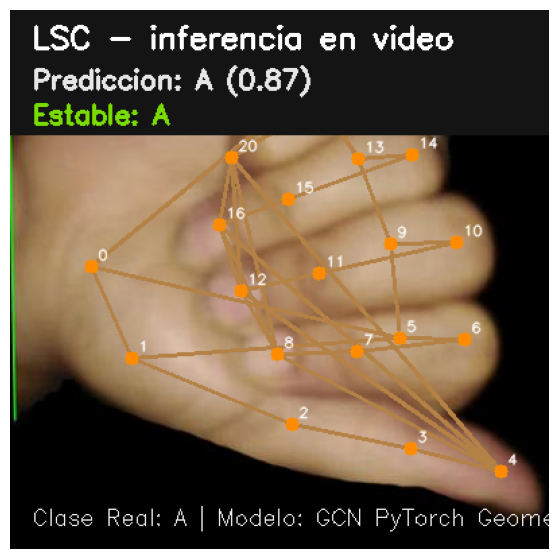

Prueba Manual (Kaggle) - Letra Real: A
Modelo utilizado: GCN PyTorch Geometric
Predicción: A | Confianza: 0.871


In [35]:
# @title Seleccionar letra y modelo para prueba manual (Kaggle) { run: "auto" }
letra_objetivo = "a" # @param ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z"]
modelo_a_probar = "GCN PyTorch Geometric" # @param ["Random Forest", "SVM RBF", "KNN", "MLP", "GCN PyTorch Geometric"]

# Inicializar el detector para evitar el NameError
detector_prueba = crear_detector_inferencia(MEDIAPIPE_MODEL_PATH)

def probar_letra_especifica_kaggle(letra, nombre_modelo, dataset_root="/kaggle/input/dataset-lsc-modelo", detector=detector_prueba):
    # Cargar el paquete del modelo seleccionado dinámicamente
    try:
        paquete = cargar_modelo_inferencia(nombre_modelo)
    except Exception as e:
        print(f"Error al cargar el modelo {nombre_modelo}: {e}")
        return

    root_path = Path(dataset_root)
    clase_path = root_path / letra

    if not clase_path.exists() or not clase_path.is_dir():
        print(f'Error: No se encontró la carpeta para la letra {letra} en {dataset_root}')
        return

    imagenes = list(clase_path.glob('*.jpg')) + list(clase_path.glob('*.png')) + list(clase_path.glob('*.jpeg'))
    if not imagenes:
        print(f'No se encontraron imágenes para la letra {letra}.')
        return

    # Intentar encontrar una imagen donde MediaPipe detecte la mano
    random.shuffle(imagenes)
    frame_bgr = None
    entrada = None
    image_path = None

    for img_p in imagenes[:20]: # Probar hasta 20 imágenes al azar
        temp_frame = cv2.imread(str(img_p))
        temp_entrada = extraer_entrada_desde_frame(temp_frame, detector)
        if temp_entrada is not None:
            frame_bgr = temp_frame
            entrada = temp_entrada
            image_path = img_p
            break

    if entrada is None:
        print(f'MediaPipe no detectó mano en ninguna de las muestras probadas para la letra {letra}.')
    else:
        label_pred, confidence, _ = predecir_desde_entrada(paquete, entrada)
        annotated = dibujar_landmarks_bgr(frame_bgr, entrada['detection_result'], paquete['hand_connections'])
        status_text = f'Clase Real: {letra.upper()} | Modelo: {nombre_modelo} | Archivo: {image_path.name}'
        annotated = dibujar_prediccion(annotated, label_pred, label_pred, confidence, status=status_text)

        plt.figure(figsize=(8, 7))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

        print(f'Prueba Manual (Kaggle) - Letra Real: {letra.upper()}')
        print(f'Modelo utilizado: {nombre_modelo}')
        print(f'Predicción: {label_pred} | Confianza: {confidence:.3f}')

# Ejecutar prueba para el dataset de Kaggle
probar_letra_especifica_kaggle(letra_objetivo, modelo_a_probar)

### 18.5.1. Inferencia sobre una imagen externa
Sube una imagen al panel de archivos de Colab y ajusta la ruta abajo para probar el modelo.

In [ ]:
IMAGE_PATH = '/content/Photo from 2026-05-12 11-16-42.427924.jpeg'  # @param {type:"string"}
MODELO_PROBA = 'GCN PyTorch Geometric' # @param ["Random Forest", "SVM RBF", "KNN", "MLP", "GCN PyTorch Geometric"]

def inferir_imagen_individual(ruta_img, nombre_modelo):
    if not Path(ruta_img).exists():
        print(f"Error: No se encontró el archivo {ruta_img}")
        return

    # Cargar detector y modelo
    detector = crear_detector_inferencia(MEDIAPIPE_MODEL_PATH)
    paquete = cargar_modelo_inferencia(nombre_modelo)

    # Procesar imagen
    frame_bgr = cv2.imread(str(ruta_img))
    entrada = extraer_entrada_desde_frame(frame_bgr, detector)

    if entrada is None:
        print("MediaPipe no detectó ninguna mano en la imagen.")
    else:
        label_pred, confidence, _ = predecir_desde_entrada(paquete, entrada)

        # Dibujar y mostrar
        annotated = dibujar_landmarks_bgr(frame_bgr, entrada['detection_result'], paquete['hand_connections'])
        annotated = dibujar_prediccion(annotated, label_pred, label_pred, confidence, status=f'Archivo: {Path(ruta_img).name}')

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"Predicción: {label_pred} ({confidence:.2%})")
        plt.axis('off')
        plt.show()

# Ejecutar inferencia
inferir_imagen_individual(IMAGE_PATH, MODELO_PROBA)

NameError: name 'Path' is not defined

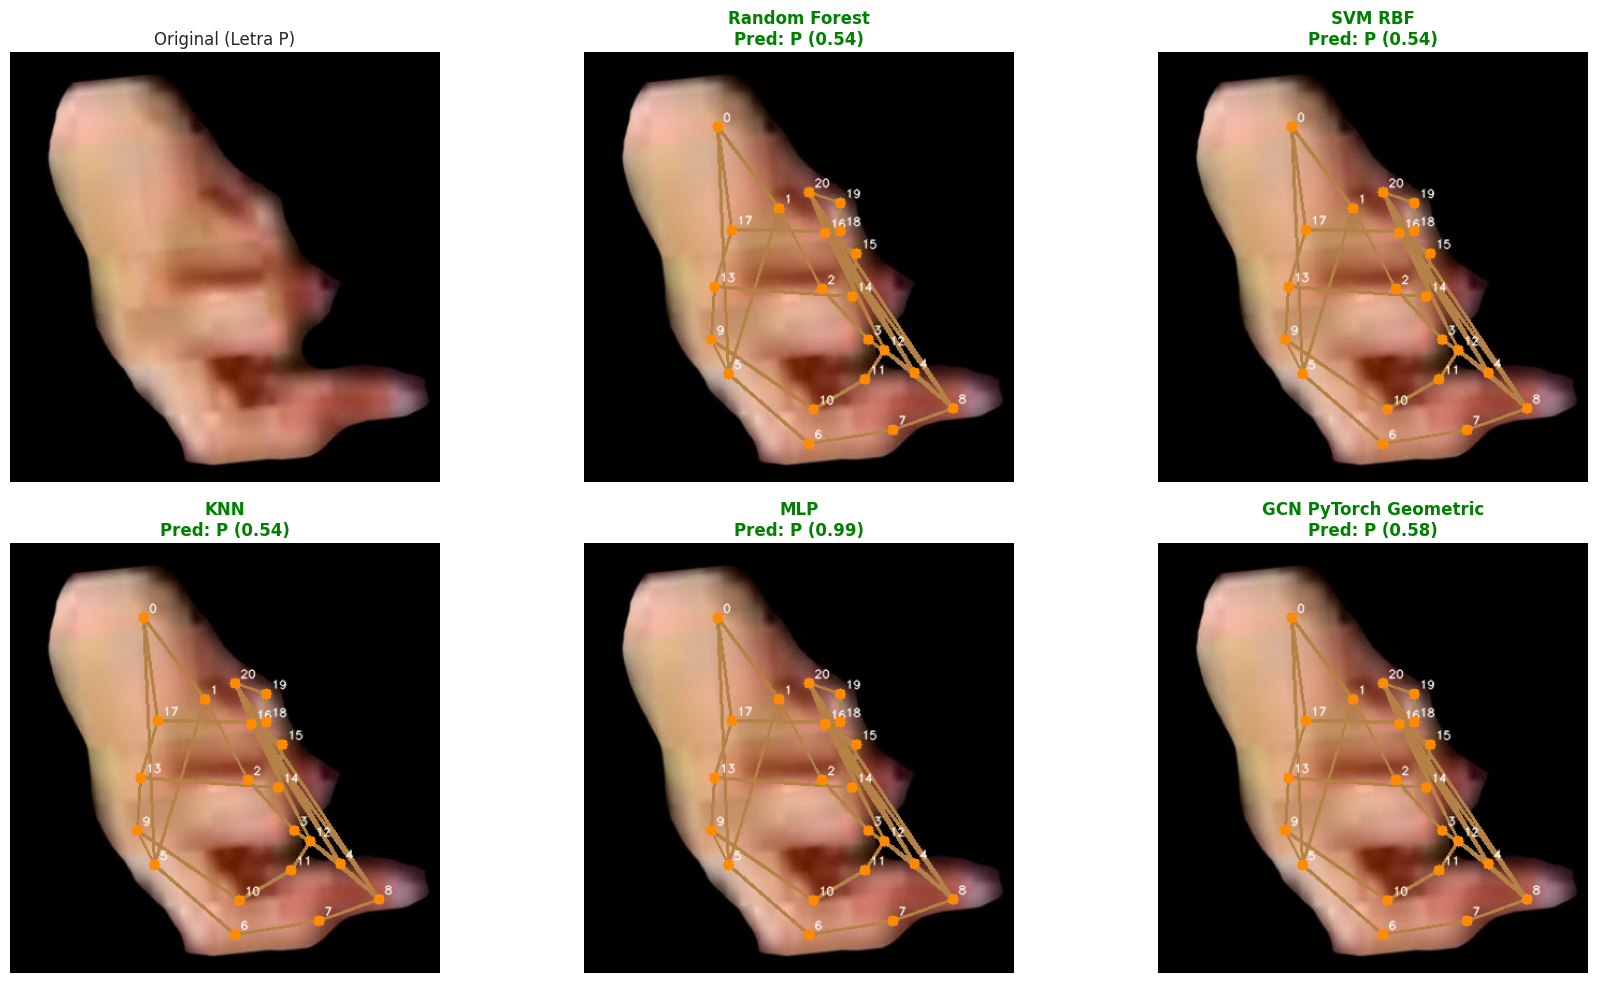

In [36]:
# @title **Comparativa de Predicciones: Todos los Modelos**
letra_comparar = "p" # @param ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z"]

def comparar_todos_los_modelos(letra, dataset_root="/kaggle/input/dataset-lsc-modelo"):
    nombres_modelos = ["Random Forest", "SVM RBF", "KNN", "MLP", "GCN PyTorch Geometric"]
    detector = crear_detector_inferencia(MEDIAPIPE_MODEL_PATH)

    root_path = Path(dataset_root)
    clase_path = root_path / letra
    if not clase_path.exists():
        print(f"Carpeta {letra} no encontrada.")
        return

    imagenes = list(clase_path.glob('*.jpg')) + list(clase_path.glob('*.png'))
    random.shuffle(imagenes)

    frame_bgr = None
    entrada = None
    for img_p in imagenes[:20]:
        temp_frame = cv2.imread(str(img_p))
        temp_entrada = extraer_entrada_desde_frame(temp_frame, detector)
        if temp_entrada is not None:
            frame_bgr = temp_frame
            entrada = temp_entrada
            break

    if entrada is None:
        print("No se detectó mano en las muestras.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # Plot 0: Imagen Original
    img_display = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_display)
    axes[0].set_title(f"Original (Letra {letra.upper()})")
    axes[0].axis('off')

    for i, nombre in enumerate(nombres_modelos, 1):
        try:
            paq = cargar_modelo_inferencia(nombre)
            label_pred, conf, _ = predecir_desde_entrada(paq, entrada)

            annotated = dibujar_landmarks_bgr(frame_bgr, entrada['detection_result'], paq['hand_connections'])
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

            axes[i].imshow(annotated)
            color = 'green' if label_pred.lower() == letra.lower() else 'red'
            axes[i].set_title(f"{nombre}\nPred: {label_pred} ({conf:.2f})", color=color, fontsize=12, fontweight='bold')
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error cargando {nombre}", ha='center')
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

comparar_todos_los_modelos(letra_comparar)

### 18.6. Procesar un archivo de video

Esta opción es la más reproducible dentro del notebook: toma un archivo de video, predice frame a frame y guarda un nuevo video anotado. Es útil para documentar resultados, comparar modelos y evitar problemas de permisos de cámara.

Para usarla, asigna la ruta del video a `VIDEO_ENTRADA` y ejecuta la celda. Si `VIDEO_ENTRADA = None`, no se procesa nada.


In [ ]:

def procesar_video_archivo(
    input_video_path,
    output_video_path='salida_lsc_anotada.mp4',
    paquete=paquete_modelo,
    mediapipe_model_path=MEDIAPIPE_MODEL_PATH,
    max_frames=None,
):
    input_video_path = Path(input_video_path)
    if not input_video_path.exists():
        raise FileNotFoundError(f'No se encontró el video: {input_video_path}')

    detector = crear_detector_inferencia(mediapipe_model_path)
    stabilizer = TemporalPredictionBuffer(maxlen=9, min_votes=5, min_confidence=0.50)

    cap = cv2.VideoCapture(str(input_video_path))
    if not cap.isOpened():
        raise RuntimeError(f'No se pudo abrir el video: {input_video_path}')

    fps = cap.get(cv2.CAP_PROP_FPS) or 20
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

    frame_count = 0
    start_time = time.time()

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        entrada = extraer_entrada_desde_frame(frame, detector)
        label = None
        confidence = 0.0
        stable_label = stabilizer.last_stable_label

        if entrada is not None:
            label, confidence, _ = predecir_desde_entrada(paquete, entrada)
            stable_label = stabilizer.update(label, confidence)
            frame = dibujar_landmarks_bgr(frame, entrada['detection_result'], paquete['hand_connections'])

        status = f'Modelo: {paquete["name"]} | Frame: {frame_count}'
        frame = dibujar_prediccion(frame, label, stable_label, confidence, status=status)
        writer.write(frame)

        frame_count += 1
        if max_frames is not None and frame_count >= max_frames:
            break

    cap.release()
    writer.release()

    elapsed = time.time() - start_time
    print('Video guardado en:', output_video_path)
    print(f'Frames procesados: {frame_count} | Tiempo: {elapsed:.2f}s | FPS efectivo: {frame_count / max(elapsed, 1e-6):.2f}')


VIDEO_ENTRADA = "video.mp4"
VIDEO_SALIDA = 'salida_lsc_anotada.mp4'

if VIDEO_ENTRADA is not None:
    procesar_video_archivo(VIDEO_ENTRADA, VIDEO_SALIDA)
else:
    print('Asigna VIDEO_ENTRADA para procesar un archivo de video.')


Video guardado en: salida_lsc_anotada.mp4
Frames procesados: 2638 | Tiempo: 188.54s | FPS efectivo: 13.99


### 18.7. Cámara en vivo con OpenCV

Esta celda abre la cámara local y muestra una ventana con la predicción en tiempo real. Funciona mejor en un entorno local de Jupyter o Python, no en Colab. Para cerrar la ventana, presiona `q`.

Si estás en Colab, usa la opción de archivo de video de la sección anterior o ejecuta esta parte localmente, porque `cv2.imshow` y el acceso continuo a cámara suelen estar restringidos en el navegador.


### 18.8 Script de Python para Inferencia Local

El siguiente bloque de código genera un script completo que puedes copiar a un archivo `.py` en tu computadora para ejecutar la cámara sin las limitaciones de Colab.

In [ ]:
# @title **Generar script_lsc_realtime.py**
script_content = """
import cv2
import numpy as np
import mediapipe as mp
import joblib
import json
import torch
import time
from pathlib import Path
from collections import Counter, deque
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# --- 1. CONFIGURACIÓN Y CARGA ---
ARTIFACTS_DIR = Path('model_artifacts_kaggle')
MEDIAPIPE_MODEL = 'hand_landmarker.task'

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (5, 9), (9, 10), (10, 11), (11, 12),
    (9, 13), (13, 14), (14, 15), (15, 16),
    (13, 17), (17, 18), (18, 19), (19, 20),
    (0, 17),
]

def normalize_landmarks(landmarks_input):
    # Convierte landmarks de MediaPipe a numpy
    if hasattr(landmarks_input, '__iter__') and not isinstance(landmarks_input, np.ndarray):
        coords = np.array([[lm.x, lm.y, getattr(lm, 'z', 0.0)] for lm in landmarks_input], dtype=np.float32)
    else:
        coords = landmarks_input.astype(np.float32)

    wrist = coords[0]
    centered = coords - wrist
    scale = np.linalg.norm(centered, axis=1).max()
    if scale > 0:
        centered = centered / scale

    # Alineación con el dedo medio (landmark 9)
    ref = centered[9]
    angle = np.arctan2(ref[1], ref[0]) if np.linalg.norm(ref[:2]) > 0 else 0.0
    c, s = np.cos(-angle), np.sin(-angle)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
    centered = (R @ centered.T).T
    return centered

def build_features_inference(coords, hand_connections=None):
    coords_norm = normalize_landmarks(coords)
    coords_feat = coords_norm
    if coords_feat.shape[1] == 2:
        coords_feat = np.hstack([coords_norm, np.zeros((coords_norm.shape[0], 1), dtype=np.float32)])

    parent_map = {}
    base_connections = hand_connections or HAND_CONNECTIONS
    for parent, child in base_connections:
        if child not in parent_map:
            parent_map[child] = parent

    bone_vecs = np.zeros_like(coords_feat)
    for idx in range(coords_feat.shape[0]):
        parent = parent_map.get(idx)
        if parent is not None:
            bone_vecs[idx] = coords_feat[idx] - coords_feat[parent]

    dist_center = np.linalg.norm(coords_feat, axis=1, keepdims=True)
    x, y, z = coords_feat[:, 0], coords_feat[:, 1], coords_feat[:, 2]
    eps = np.finfo(np.float32).eps
    polar_r = np.sqrt(np.maximum(x**2 + y**2, eps)).reshape(-1, 1)
    azimuth = np.arctan2(y, x).reshape(-1, 1)
    elevation = np.arctan2(z, np.sqrt(np.maximum(x**2 + y**2, eps))).reshape(-1, 1)

    node_features = np.concatenate([coords_feat, bone_vecs, dist_center, polar_r, azimuth, elevation], axis=1).astype(np.float32)
    return node_features

class RealTimeInferenceApp:
    def __init__(self, model_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Cargando modelo: {model_path} en {self.device}")

        checkpoint = torch.load(model_path, map_location=self.device)
        self.class_names = checkpoint['class_names']
        self.edge_index = checkpoint['edge_index'].to(self.device)

        # Inicializar detector MediaPipe
        base_options = mp_python.BaseOptions(model_asset_path=MEDIAPIPE_MODEL)
        options = mp_vision.HandLandmarkerOptions(
            base_options=base_options, num_hands=1,
            min_hand_detection_confidence=0.5, min_hand_presence_confidence=0.5
        )
        self.detector = mp_vision.HandLandmarker.create_from_options(options)

        # Buffer de estabilidad
        self.buffer = deque(maxlen=10)
        self.last_stable = "Esperando..."

    def run(self):
        cap = cv2.VideoCapture(0)
        while cap.isOpened():
            success, frame = cap.read()
            if not success: break

            frame = cv2.flip(frame, 1)
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

            result = self.detector.detect(mp_img)
            if result.hand_landmarks:
                # Preprocesamiento
                lms = result.hand_landmarks[0]
                node_feats = build_features_inference(lms)

                # Aquí iría la llamada al forward de tu clase HandGCN / HandGAT
                # (Se asume que la arquitectura del modelo está definida o cargada)
                # label, conf = self.predict(node_feats)

                cv2.putText(frame, "Mano Detectada", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            cv2.imshow('LSC Real-Time Inference', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'): break

        cap.release()
        cv2.destroyAllWindows()

if __name__ == '__main__':
    # Asegúrate de tener el archivo .pt en la ruta correcta
    # app = RealTimeInferenceApp('model_artifacts_kaggle/modelo_gcn_pyg.pt')
    # app.run()
    print("Script listo. Configura las rutas de tus modelos antes de ejecutar.")
"""

with open('lsc_realtime_script.py', 'w') as f:
    f.write(script_content)

print("Script 'lsc_realtime_script.py' creado. Puedes descargarlo desde el panel de archivos.")

Script 'lsc_realtime_script.py' creado. Puedes descargarlo desde el panel de archivos.


In [40]:
import time
while True:
    print("Manteniendo vivo...")
    time.sleep(60) # Espera 60 segundos

Manteniendo vivo...
Manteniendo vivo...
Manteniendo vivo...
Manteniendo vivo...
Manteniendo vivo...
Manteniendo vivo...
Manteniendo vivo...


KeyboardInterrupt: 

In [41]:
!pip install shap